# Capstone Project Notebook
Authors: Jason Wang, Ivan Chan, Amy Wang, Pallavi Venkatesh, Brynn Minko

List of Functions In This Notebook
Simulation
│
random_walk_1d()
simulate_randome_walks()
simulate_random_walks_2d()

initialize_concentration()
diffusion_step()
simulate_diffusion()

generate_porous_grid()
simulate_random_walks_2d_porous()
diffusion_step_porous()
simulate_diffusion_porous()

Analysis
│
compute_msd()
estimate_diffusion()

check_mass_conservation()
check_negative_concentration()
analytical_solution()
compute_rmse()



Visualization
│
plot_random_walk_1d()
plot_random_walk_2d()

plot_concentration_field()

plot_porous_grid()
plot_random_walk_2d_porous()

## Introduction & Project Goals

### Objective & Significance

For our project, we would like to computationally study how microscopic restrictions (porosity and pore geometry) affect macroscopic diffusion behavior in porous media by simulating the diffusion process using the Particle-Based Brownian random-walk model and the Continuum Diffusion-equation model. The simulation results will be further compared to examine the tendency each model exhibits under the same conditions. 

This project connects microscopic particle motion with macroscopic transport behavior. It is relevant to diffusion in membranes, catalysts, filters, soils, biological tissues, and battery electrodes. The project also follows a standard computational physics workflow: build a simple model, validate it against known equations, extend it to more complex systems, and compare different numerical methods.

### Research Question

In this project, we would investigate how the internal structure of a porous medium influences diffusion and to compare two computational approaches for modeling this process.

Specifically, this project seeks to answer the following question:

> **How do porosity and pore geometry affect diffusion, and how do particle-based and continuum models compare when simulating diffusion through porous media?**

Rather than relying on a single computational method, we will be using two independent models, Brownian Motion and Continuum Model. Comparing these approaches provides additional confidence in the numerical results while highlighting the advantages and limitations of each method.

To answer this research question, we first establish a set of project objectives that guide the implementation and validation of both computational models.

### Project Objectives

This project is organized into several objectives:

1. Develop a particle-based random walk model that simulates diffusion through individual particle motion.

2. Develop a continuum diffusion model by numerically solving the diffusion equation on a two-dimensional grid.

3. Validate both computational models using free diffusion before introducing porous media.

4. Introduce porous structures into both simulations while maintaining equivalent physical conditions.

5. Compare the behavior of both models under varying porosity.

6. Quantify how porosity influences the effective diffusion coefficient.

Successfully completing these objectives provides both a computational comparison between modeling approaches and a physical investigation of diffusion in porous media.

Achieving these objectives requires two different computational models, each representing diffusion from a different perspective.

The particle-based model follows the trajectories of individual particles undergoing random motion. Because each particle is simulated explicitly, this approach provides an intuitive representation of Brownian motion and allows individual trajectories to be visualized directly. The model naturally captures stochastic behavior and individual particle motion but can become computationally expensive when simulating large numbers of particles.

In contrast, the continuum model does not track individual particles. Instead, it describes the evolution of particle concentration by numerically solving the diffusion equation over the entire domain. This model is computationally efficient for large systems and directly predicts concentration fields, although it does not provide information about individual particle trajectories.

By developing both models, we can compare their predictions, evaluate their respective strengths and limitations, and gain greater confidence that both approaches describe the same underlying physical process.

### Project Roadmap

The following roadmap outlines how these models will be developed, validated, and ultimately compared throughout the project.

1. Define the scientific problem and project objectives.

2. Develop a particle-based random walk model.

3. Validate the particle model using free diffusion.

4. Develop a continuum diffusion solver.

5. Validate the continuum model.

6. Ensure both models represent equivalent physical systems.

7. Introduce porous media into both models.

8. Compare the behavior of both models under different porosities.

9. Analyze the results and draw scientific conclusions.

This workflow ensures that each model is validated before being used to investigate diffusion within porous media.

## Random Walk Model

### Brownian Motion

Brownian motion is the random motion of microscopic particles caused by continual collisions with surrounding molecules. While the motion of an individual particle is unpredictable, the collective behavior of many particles can be described statistically. This microscopic random motion gives rise to diffusion at the macroscopic scale [(MIT)](https://web.mit.edu/8.334/www/grades/projects/projects17/OscarMickelin/brownian.html).

Since directly simulating every molecular collision is computationally impractical, Brownian motion is commonly approximated using a random walk. In a random walk, a particle moves one step in a randomly selected direction at each time step. As the number of simulated particles increases, their collective behavior approximates the diffusion process.

For this project, we will use the random walk algorithm to simulate Brownian motion. We will first implement a simple one-dimensional random walk to reproduce the expected behavior of free diffusion. The model will then be extended to two dimensions, where particles move through a two-dimensional domain. After validating the free-diffusion model, porous structures represented by solid obstacle cells will be introduced to restrict particle motion. 


### Random Walk Model

A random walk represents particle motion as a sequence of discrete steps taken in random directions. During each time step, a particle moves a fixed distance while the direction of motion is chosen randomly. Although this model is considerably simpler than the true microscopic dynamics of Brownian motion, it reproduces many of the same statistical properties when observed over sufficiently long times.

#### Key Assumptions

To simplify the model, we make the following assumptions:

- Particles do not interact with one another.
- Each step is independent of previous steps.
- Every direction is equally likely.
- Step length remains constant.
- Time advances in equal increments.
- External forces are neglected.

These assumptions isolate the essential physics of diffusion while keeping the computational model straightforward.

### Model Implementation

#### Model Design

Each particle is represented by its position within the computational domain.

During every simulation step:

1. Select a random direction.
2. Move the particle by one step.
3. Record its updated position.
4. Repeat for every particle.

Initially, we begin with a one-dimensional random walk to verify the implementation before extending the model to two dimensions.

The implementation will later be generalized to simulate many particles simultaneously.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
#import scipy as scy
#from  matplotlib.widgets import Slider

In [2]:
# Simple 1D Random Walk Simulation (TBW)
## Simulate 1D random walk of a single particle.
# Code Starts Here

def random_walk_1d(n_steps: int, 
                   start_pos: float = 0, 
                   step_size: float = 1, 
                   seed: int = None):
    """
    Parameters
    ----------
    n_steps : int
        Number of time steps.
    start_pos : float
        Initial position of the particle. Default is 0.
    step_size : float
        Distance traveled in each step.
    seed : int or None
        Random seed for reproducibility.

    Returns
    -------
    array
        Particle position at each time step.
    """

    # Parameter check
    if n_steps < 0:
        raise ValueError("n_steps must be non-negative.")

    if step_size <= 0:
        raise ValueError("step_size must be positive.")

    # Main Code
    if seed is not None:
        random.seed(seed)

    position = start_pos
    trajectory = [position]

    for _ in range(n_steps):
        step = random.choice([-step_size, step_size])
        position += step
        trajectory.append(position)

    return np.array(trajectory)

# Simple test
random_walk_1d(n_steps = 100)

array([ 0,  1,  2,  1,  0,  1,  0, -1, -2, -1,  0,  1,  2,  1,  2,  1,  2,
        1,  0, -1,  0,  1,  0,  1,  2,  3,  2,  3,  4,  5,  4,  5,  6,  5,
        6,  7,  6,  5,  4,  5,  4,  3,  2,  3,  2,  1,  2,  3,  4,  3,  4,
        5,  6,  5,  6,  5,  4,  3,  2,  3,  4,  3,  2,  1,  2,  3,  4,  3,
        2,  1,  0,  1,  0, -1,  0,  1,  2,  3,  2,  1,  2,  1,  2,  3,  2,
        1,  2,  1,  0,  1,  2,  1,  0,  1,  0,  1,  0, -1, -2, -1,  0])

### Visualizing Particle Motion

Visualizing individual particle trajectories provides an important qualitative check of the implementation. Because each step is chosen randomly, successive trajectories should appear irregular and unpredictable while exhibiting no preferred direction. Although individual trajectories differ significantly from one another, they are all generated from the same statistical rules.

These visualizations help confirm that the algorithm correctly implements random motion before more quantitative analyses are performed.

In [3]:
# Function for plotting the trajectory of a one-dimensional random walk
def plot_random_walk_1d(trajectory):
    """
    Plot the trajectory of a one-dimensional random walk.
    """

    trajectories = np.asarray(trajectory)

    fig, ax = plt.subplots(figsize = (8, 4))

    if trajectories.ndim == 1:

        time = np.arange(len(trajectories))

        ax.plot(time, trajectories, linewidth = 1.5, alpha = 0.7)
        ax.scatter(time, trajectories, s = 15)

    elif trajectories.ndim == 2:

        time = np.arange(trajectories.shape[1])

        for trajectory in trajectories:
            ax.plot(time, trajectory, linewidth = 1, alpha = 0.7)

    else:
        raise ValueError("Input must be a 1D or 2D array.")

    ax.axhline(0, linestyle = "--", color = "gray", label = "Starting Position")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Position")
    ax.set_title("One-Dimensional Random Walk")
    ax.grid(True)
    ax.legend()

    plt.show()

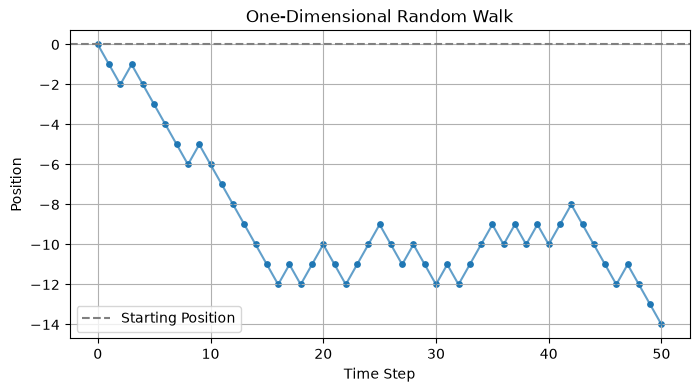

In [4]:
# Visualization
trajectory = random_walk_1d(
    n_steps= 50,
    start_pos= 0,
    step_size= 1,
    seed = 42
)

plot_random_walk_1d(trajectory)

#### Observations
- Although the particle has an equal probability of moving one step to the left or right at each time step, this particular simulation exhibits an overall drift toward the left. This occurs purely due to random chance.
- The particle does not move smoothly in a single direction. Instead, it repeatedly changes direction throughout the simulation, producing the irregular trajectory characteristic of a random walk.
- The particle revisits previously occupied positions multiple times rather than continuously exploring new locations.
- Despite the overall displacement toward the left, the particle's motion remains completely stochastic because every individual step is determined independently with equal probability.

### Many-Particle Simulation

Diffusion is not characterized by the motion of a single particle but rather by the collective behavior of a large ensemble of particles. As the number of simulated particles increases, random fluctuations become less pronounced, and statistical patterns begin to emerge. 

Instead of examining individual trajectories, we now investigate the distribution of particle positions over time.

In [5]:
# Many-Particle Random Walk Simulation (1D)
## Simulation random walks of many particles in one dimension.

# Code Starts Here
def simulate_random_walks(n_particles: int, 
                          n_steps: int, 
                          start_pos: float = 0, 
                          step_size: float = 1, 
                          seed: int = None):
    """
    Simulate many particles performing a one-dimensional random walk.

    Parameters
    ----------
    n_particles : int
        Number of particles to simulate.
    n_steps : int
        Number of time steps for each particle.
    start_pos : float
        Initial position of the particles. Default is 0.
    step_size : float
        Distance traveled in each step.
    seed : int or None
        Random seed for reproducibility.

    Returns
    -------
    array
        Array of shape (n_particles, n_steps + 1), where each row contains the trajectory of one particle.
    """

    # Parameter check
    if n_particles <= 0:
        raise ValueError("n_particles must be positive.")

    if n_steps < 0:
        raise ValueError("n_steps must be non-negative.")

    if step_size <= 0:
        raise ValueError("step_size must be positive.")

    # Main Code
    if seed is not None:
        random.seed(seed)

    # Initialize positions array
    trajectories = []

    for _ in range(n_particles):
        trajectories.append(random_walk_1d(n_steps, start_pos, step_size))

    return np.array(trajectories)

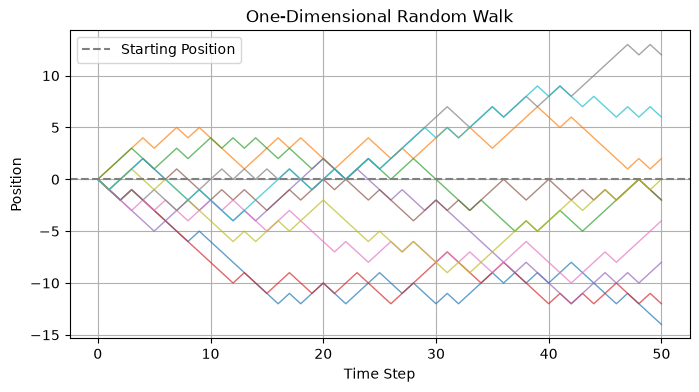

In [6]:
# One example for many-particle random walks
trajectories = simulate_random_walks(
    n_particles= 10,
    n_steps= 50,
    start_pos= 0,
    step_size= 1,
    seed = 42)
plot_random_walk_1d(trajectories)

#### Observations
- With 10 particles simulated under the same random walk model, each particle follows a unique trajectory despite all particles starting from the same initial position. This demonstrates that the random walk algorithm correctly generates independent stochastic motion for each particle.
- All particles begin at the same initial position ($x = 0$), but their trajectories gradually diverge over time due to the randomness of each step.
- Although individual particles may drift significantly to the left or right, the ensemble of trajectories exhibits no obvious preferred direction. This is consistent with each step having an equal probability of moving left or right.
- The spread of particle positions increases over time. Although every particle begins at the same location, the range of positions becomes progressively larger as the random walks evolve.

### Summary

In this section, we developed a particle-based random walk model as a computational approximation of Brownian motion. Beginning with the physical motivation provided by Brownian motion, we introduced the random walk model, described its underlying assumptions, and implemented a numerical simulation capable of tracking individual particle motion.

Visualizations of both single-particle trajectories and many-particle simulations demonstrated the expected qualitative behavior of random motion. These results provide confidence that the implementation is functioning correctly and establish the computational foundation for studying diffusion.

At this stage, the model has only been evaluated qualitatively. Although the particle trajectories appear physically reasonable, we have not yet verified that the simulation reproduces the quantitative properties of diffusion. We would then focuses on validating the particle model by measuring quantities such as the mean squared displacement (MSD) and estimating the diffusion coefficient. These analyses will determine whether the random walk accurately reproduces the expected behavior of free diffusion.

## Validating the Random Walk Model

### Introduction

In previous section, we developed a one-dimensional random walk simulation capable of generating independent particle trajectories. While the simulation produces qualitatively realistic Brownian motion, we need to verify that the model correctly reproduces the statistical behavior of diffusion.

We would validate the particle-based model by comparing its numerical results with established theoretical predictions. Specifically, we will examine how the mean squared displacement (MSD) evolves over time, estimate the corresponding diffusion coefficient, and investigate how increasing the number of simulated particles affects the statistical reliability of the measurements.

Successful validation in the free-diffusion case provides confidence that the model is implemented correctly before extending it to higher dimensions and, ultimately, to diffusion through porous media.

### Mean Squared Displacement (MSD)

Individual random walk trajectories exhibit significant variability because each particle undergoes an independent sequence of random steps. Consequently, the displacement of a single particle is not sufficient for characterizing diffusive motion. Instead, diffusion is described statistically by averaging over a large ensemble of independent particles.

The primary quantity used in this milestone is the **mean squared displacement (MSD)**, defined as

$$ \mathrm{MSD}(t) = \left<\left[x(t)-x_0\right]^2\right>,$$

where

- $x(t)$ is the particle position at time $t$,
- $x_0$ is the initial particle position,
- $\langle\cdot\rangle$ denotes the average over all simulated particles.

The displacement is squared before averaging so that particles moving in opposite directions contribute equally to the overall spreading of the particle distribution.

For an ideal one-dimensional diffusion process, theory predicts that the mean squared displacement grows linearly with time,

$$
\mathrm{MSD}(t)=2Dt,
$$

where

- $D$ is the diffusion coefficient,
- $t$ is time.

Therefore, a correctly implemented random walk should produce an approximately linear MSD curve whose slope is proportional to the diffusion coefficient.

To compute the mean squared displacement:

1. Determine each particle's displacement from its initial position.
2. Square the displacement of every particle.
3. Average the squared displacements across all particles at each time step.

The resulting one-dimensional array contains the MSD as a function of time and can be compared directly with the theoretical prediction for normal diffusion.

In [7]:
# Function to calculate the mean squared displacement (MSD)
## Compute the Mean Squared Displacement (MSD) of an ensemble of particle trajectories.

# Code Starts Here
def compute_msd(trajectories):
    """
    Parameters
    ----------
    trajectories : array
        Particle trajectories, either in 1D or multi-dimensional space.

        Examples
        ----------------
        1D trajectories:
            (n_particles, n_steps + 1)

        Multi-dimensional trajectories:
            (n_particles, n_steps + 1, dimensions)

    Returns
    -------
    array
        Mean squared displacement at each time step.
        Shape: (n_steps + 1,)
    """

    trajectories = np.asarray(trajectories)

    if trajectories.ndim not in (2, 3):
        raise ValueError(
            "Trajectories must have shape "
            "(n_particles, n_steps + 1) or "
            "(n_particles, n_steps + 1, dimensions)."
        )

    # Initial particle positions
    initial_positions = trajectories[:, 0]

    # Displacement from initial position
    displacement = trajectories - initial_positions[:, np.newaxis]

    if trajectories.ndim == 2:
        squared_displacement = displacement ** 2
    else:
        squared_displacement = np.sum(displacement ** 2, axis=-1)

    msd = np.mean(squared_displacement, axis=0)

    return msd

In [8]:
# Example
# trajectories from last section
trajectories = simulate_random_walks(
    n_particles= 10,
    n_steps= 50,
    start_pos= 0,
    step_size= 1,
    seed = 42)
msd = compute_msd(trajectories)
print(msd)

[ 0.   1.   2.8  4.2  6.   6.6  7.6 11.4 12.4 13.8 16.4 20.2 26.  22.6
 29.6 33.  30.4 25.8 30.  29.  25.2 30.6 30.  29.  33.2 29.  33.6 37.8
 33.2 37.8 41.2 41.8 42.8 45.  46.  45.8 43.2 46.6 50.  56.2 60.4 61.
 64.  59.4 61.2 56.2 60.4 59.4 60.8 61.8 61.2]


The computed MSD increases with time, indicating that the particle ensemble spreads farther from its initial position as the random walk progresses. 

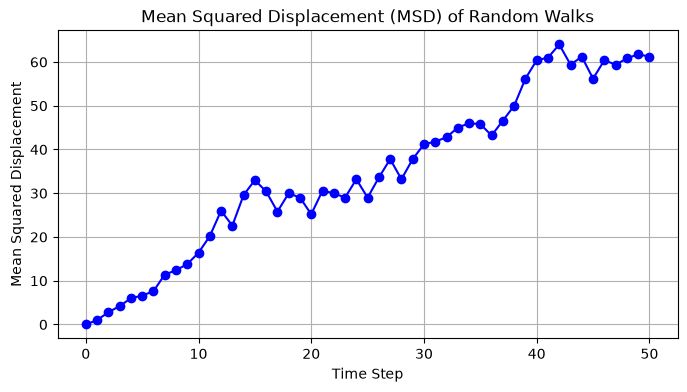

In [9]:
# Visualization of the MSD example
plt.figure(figsize=(8, 4))
plt.plot(msd, marker='o', linestyle='-', color='b')
plt.title("Mean Squared Displacement (MSD) of Random Walks")
plt.xlabel("Time Step")
plt.ylabel("Mean Squared Displacement")
plt.grid(True)
plt.show()

#### Observations

- The mean squared displacement (MSD) increases with time, indicating that the ensemble of particles gradually spreads away from its initial position during the random walk.
- Although the overall trend is increasing, the MSD curve exhibits noticeable fluctuations rather than forming a perfectly straight line. These fluctuations arise from the stochastic nature of the random walk and the limited number of particles included in the ensemble average.
- With only 10 simulated particles, individual trajectories have a relatively large influence on the computed MSD, resulting in a noisy estimate of the expected linear relationship between MSD and time.
- Despite these statistical fluctuations, the simulation reproduces the qualitative behavior expected for normal diffusion, where the average squared displacement increases approximately linearly with time.

### Estimation of the Diffusion Coefficient (D)

While the mean squared displacement provides a qualitative measure of particle spreading, often we would use the diffusion coefficient to describes the rate at which particles spread through the medium.

The diffusion coefficient will be estimated from the simulated MSD data and compared with its theoretical value. Agreement between the simulated and theoretical diffusion coefficients provides quantitative validation of the random walk model.

For one-dimensional diffusion, the mean squared displacement is related to time by

$$
\mathrm{MSD}(t)=2Dt,
$$

where

- $\mathrm{MSD}(t)$ is the mean squared displacement,
- $D$ is the diffusion coefficient,
- $t$ is time.

Since the relationship between MSD and time is linear, the diffusion coefficient can be obtained from the slope of the MSD curve.

Let

$$
m=\frac{d(\mathrm{MSD})}{dt},
$$

denote the slope of the fitted line. Rearranging the diffusion equation gives

$$
D=\frac{m}{2}.
$$

Therefore, estimating the diffusion coefficient reduces to fitting a straight line to the simulated MSD data and computing half of its slope.

The simulated MSD values are fitted using a least-squares linear regression. The resulting slope represents the rate of increase of the mean squared displacement with respect to time.

Using the fitted slope, the diffusion coefficient is calculated according to

$$
D=\frac{\text{slope}}{2}.
$$

The estimated diffusion coefficient is then compared with the theoretical value expected for the random walk model.

In [128]:
# Function for estimating the diffusion coefficient from the MSD
## Estimate the diffusion coefficient from the mean squared displacement.
# Code Starts Here
def estimate_diffusion(msd, 
                       dt: float =1, 
                       dimensions: int =1):
    """
    Parameters
    ----------
    msd : array
        Mean squared displacement values.

    dt : float, optional
        Time step size.

    dimensions : int, optional
        Number of spatial dimensions.

    Returns
    -------
    D : float
        Estimated diffusion coefficient.

    slope : float
        Slope of the fitted MSD curve.

    intercept : float
        Intercept of the fitted line.
    """

    time = np.arange(len(msd)) * dt

    slope, intercept = np.polyfit(time, msd, 1)

    D = slope / (2 * dimensions)

    return D, slope, intercept

In [11]:
# Example using the msd from the previous section
D, slope, intercept = estimate_diffusion(msd)

print("Slope = ", slope)
print("Estimated D = ", D)

Slope =  1.2511493212669682
Estimated D =  0.6255746606334841


#### Comparison with the Theoretical Diffusion Coefficient

For the present simulation, the theoretical diffusion coefficient is

$$
D=\frac{(\Delta x)^2}{2\Delta t}=0.5,
$$

using a unit step length ($\Delta x=1$) and a unit time step ($\Delta t=1$).

The estimated diffusion coefficient obtained from the fitted MSD curve is reasonably close to the theoretical value, indicating that the random walk simulation reproduces the expected diffusive behavior.

The small discrepancy between the estimated and theoretical values is primarily attributed to statistical fluctuations arising from the limited number of simulated particles. As the number of particles increases, the estimated diffusion coefficient is expected to converge toward the theoretical prediction.

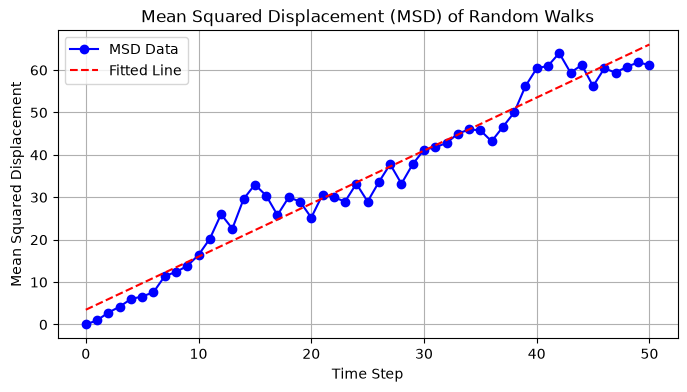

In [12]:
# Overlay the fitted line on the MSD plot
plt.figure(figsize=(8, 4))
plt.plot(msd, marker='o', linestyle='-', color='b', label='MSD Data')
plt.plot(np.arange(len(msd)), slope * np.arange(len(msd)) + intercept, linestyle='--', color='r', label='Fitted Line')
plt.title("Mean Squared Displacement (MSD) of Random Walks")
plt.xlabel("Time Step")
plt.ylabel("Mean Squared Displacement")
plt.grid(True)
plt.legend()
plt.show()

#### Observations

- The fitted line captures the overall increasing trend of the mean squared displacement (MSD), indicating that the simulated particle ensemble exhibits the approximately linear growth expected for normal diffusion.
- Although the MSD data fluctuates around the fitted line, these deviations are expected because the ensemble consists of only 10 independent particle trajectories. With a relatively small sample size, individual trajectories have a greater influence on the ensemble average, leading to increased statistical noise.
- Despite the fluctuations, the fitted line provides a reasonable approximation of the long-term behavior of the MSD, suggesting that the simulated random walk follows the theoretical diffusion model on average.
- The slope of the fitted line provides an estimate of the diffusion coefficient, which can be compared with the theoretical value to quantitatively validate the random walk model.

### Effect of Sample Size

The previous sections demonstrated that the particle-based random walk reproduces the expected linear relationship between the mean squared displacement (MSD) and time. However, the estimated diffusion coefficient depends on the number of independent particle trajectories included in the ensemble average.

We would investigate how the number of simulated particles influences the statistical noise of the MSD and the accuracy of the estimated diffusion coefficient. By repeating the simulation with progressively larger particle ensembles, we can evaluate the convergence of the numerical estimate toward the theoretical diffusion coefficient.

The MSD is calculated as an ensemble average over all simulated particles,

$$
\mathrm{MSD}(t)=
\frac{1}{N}
\sum_{i=1}^{N}
[x_i(t)-x_i(0)]^2,
$$

where $N$ is the number of particles.

As the number of particles increases, random fluctuations from individual trajectories become less significant, producing a smoother MSD curve and a more reliable estimate of the diffusion coefficient.

To examine the effect of sample size, the random walk simulation is repeated using different ensemble sizes while keeping all other simulation parameters unchanged. For each ensemble size:

1. Generate the particle trajectories.
2. Compute the mean squared displacement.
3. Estimate the diffusion coefficient from a linear fit to the MSD.
4. Compare the estimated diffusion coefficient with the theoretical value.

The results are then compared to evaluate the influence of sample size on the accuracy and stability of the simulation.

In [13]:
particle_counts = [10, 100, 1000, 10000]

results = []

for n_particles in particle_counts:

    trajectories = simulate_random_walks(
        n_particles=n_particles,
        n_steps=50,
        seed=42
    )

    msd = compute_msd(trajectories)

    D, slope, intercept = estimate_diffusion(msd)

    theoretical_D = 0.5

    relative_error = abs(D - theoretical_D) / theoretical_D * 100

    results.append([
        n_particles,
        D,
        relative_error
    ])

print(f"{'Particles':<12}{'Estimated D':<15}{'Relative Error (%)'}")

for n, D, error in results:
    print(f"{n:<12}{D:<15.4f}{error:.2f}")
print("Theoretical D = ", theoretical_D)

Particles   Estimated D    Relative Error (%)
10          0.6256         25.11
100         0.5071         1.42
1000        0.5386         7.72
10000       0.4934         1.31
Theoretical D =  0.5


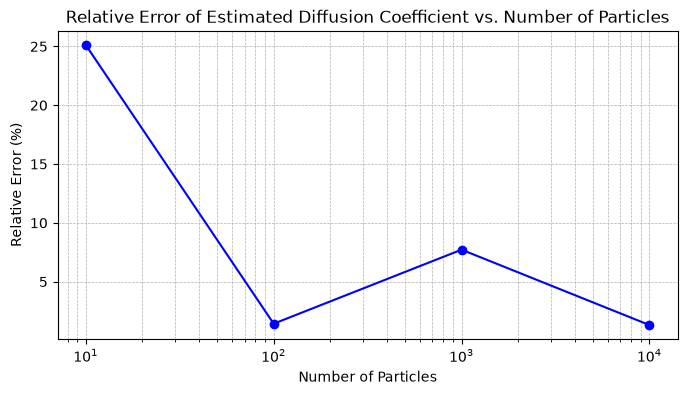

In [14]:
# Plot of the relative error
plt.figure(figsize=(8, 4))
plt.plot(particle_counts, [error for _, _, error in results], marker='o', linestyle='-', color='b')
plt.title("Relative Error of Estimated Diffusion Coefficient vs. Number of Particles")
plt.xlabel("Number of Particles")
plt.ylabel("Relative Error (%)")
plt.xscale('log')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

#### Observations

- The estimated diffusion coefficient becomes progressively more accurate as the number of simulated particles increases, demonstrating improved agreement with the theoretical diffusion coefficient.
- The relative error generally decreases with increasing sample size, indicating that larger particle ensembles provide more reliable estimates of the diffusion coefficient.
- Although the 100-particle simulation produced a smaller relative error than the 1000-particle simulation in this particular experiment, this does not contradict the overall trend. Because each simulation is subject to random statistical fluctuations, and individual realizations may occasionally produce more accurate or less accurate estimates by chance.
- As the ensemble size reaches 10,000 particles, the estimated diffusion coefficient converges very closely to the theoretical value, demonstrating that the random walk simulation approaches the expected diffusive behavior as statistical sampling improves.
- These results highlight the importance of ensemble averaging in Monte Carlo simulations, where increasing the number of independent particle trajectories reduces statistical uncertainty and improves the reliability of the numerical solution.

In [15]:
# Extension: Running this simulation for number of times
results = {
    n: {"D": [], "error": []}
    for n in particle_counts
}

theoretical_D = 0.5

for seed in range(20):

    for n_particles in particle_counts:

        trajectories = simulate_random_walks(
            n_particles=n_particles,
            n_steps=50,
            seed=seed
        )

        msd = compute_msd(trajectories)

        D, slope, intercept = estimate_diffusion(msd)

        relative_error = abs(D - theoretical_D) / theoretical_D * 100

        results[n_particles]["D"].append(D)
        results[n_particles]["error"].append(relative_error)


print(f"{'Particles':<12}{'Mean D':<12}{'Mean Error (%)'}")

for n in particle_counts:

    mean_D = np.mean(results[n]["D"])
    mean_error = np.mean(results[n]["error"])

    print(f"{n:<12}{mean_D:<12.4f}{mean_error:.2f}")

print("Theoretical D =", theoretical_D)

Particles   Mean D      Mean Error (%)
10          0.4883      38.80
100         0.4896      13.21
1000        0.4981      5.40
10000       0.5016      0.90
Theoretical D = 0.5


### Summary

In this section, the one-dimensional random walk model was quantitatively validated using the mean squared displacement (MSD). The simulated MSD exhibited the approximately linear relationship with time expected for normal diffusion, confirming that the particle ensemble spreads according to the theoretical diffusion model.

A linear regression was performed on the simulated MSD data to estimate the diffusion coefficient. The estimated values were found to be in good agreement with the theoretical diffusion coefficient, demonstrating that the numerical implementation accurately reproduces the expected diffusive behavior.

The influence of sample size was also investigated by repeating the simulation with progressively larger particle ensembles. While simulations with fewer particles produced noisier MSD curves and larger variations in the estimated diffusion coefficient, increasing the number of particles reduced statistical fluctuations and improved agreement with the theoretical prediction. These results highlight the importance of ensemble averaging in Monte Carlo simulations and provide confidence that the random walk model has been correctly implemented.

Having validated the one-dimensional random walk model, the next section extends the simulation to two dimensions, where particle motion occurs independently along both the x- and y-directions while preserving the same statistical properties of diffusion.

## From 1D to 2D Random Walk Model

### Introduction

The one-dimensional random walk developed previously provides a useful model for studying diffusive motion. However, many physical diffusion processes occur in two or three spatial dimensions rather than along a single line. To better represent these systems, the particle model is extended to two dimensions.

In this section, particles are allowed to move freely on a two-dimensional square lattice. Each particle moves one lattice spacing at every time step by randomly selecting one of the four cardinal directions. This two-dimensional model forms the basis for the porous media simulations developed in later sections.

### Random Walks in Two Dimensions

In the two-dimensional model, the position of a particle is represented by the vector

$$
\mathbf{r}(t)=
\begin{bmatrix}
x(t)\\
y(t)
\end{bmatrix},
$$

where $x(t)$ and $y(t)$ denote the particle's horizontal and vertical positions, respectively.

At every time step, the particle moves one lattice spacing by randomly selecting one of four possible directions:

- Right: $(1,0)$
- Left: $(-1,0)$
- Up: $(0,1)$
- Down: $(0,-1)$

Each direction is chosen with equal probability,

$$
P(\text{right}) = P(\text{left}) = P(\text{up}) = P(\text{down}) = \frac{1}{4}.
$$

Since all four directions are equally likely, the random walk remains **unbiased**, meaning there is no preferred direction of motion. Over many independent realizations, the average displacement remains zero, while the particles gradually spread throughout the two-dimensional domain.

To avoid repepitive code from one particle to multiple particle simulation, the 2D random walks function builds upon the 1D simulation code.

In [ ]:
# Function to simulate 2d random walks
## Simulate multiple independent 2D random walks.
## Code is build upon the 1D random walk simulation code.
# Code Starts Here

def simulate_random_walks_2d(
    n_particles: int,
    n_steps: int,
    start_pos: tuple = (0, 0),
    step_size: float = 1,
    seed: int = None
):
    """
    Parameters
    ----------
    n_particles : int
        Number of particles to simulate.
    n_steps : int
        Number of time steps.
    start_pos : tuple, optional
        Initial (x, y) position of each particle.
    step_size : float, optional
        Distance traveled in each step.
    seed : int, optional
        Random seed for reproducibility.

    Returns
    -------
    array
        Array of particle trajectories with shape
        (n_particles, n_steps + 1, 2).
    """
    # Parameter check
    if n_particles <= 0:
        raise ValueError("n_particles must be positive.")

    if n_steps <= 0:
        raise ValueError("n_steps must be positive.")

    if seed is not None:
        random.seed(seed)

    # Main code
    moves = [
        ( step_size, 0),
        (-step_size, 0),
        (0,  step_size),
        (0, -step_size)
    ]

    # Function to generate a single 2D random walk
    def single_walk():
        """Generate one 2D random walk."""

        x, y = start_pos
        trajectory = [(x, y)]

        for _ in range(n_steps):
            dx, dy = random.choice(moves)

            x += dx
            y += dy

            trajectory.append((x, y))

        return np.array(trajectory)

    trajectories = []

    for _ in range(n_particles):
        trajectories.append(single_walk())

    return np.array(trajectories)

### Visualizing 2D Particle Motions

In [17]:
# Function to plot 2D random walk trajectories
## Plot one or more 2D random walk trajectories.
# Code Starts Here

def plot_random_walk_2d(trajectories):
    """
    Parameters
    ----------
    trajectories : numpy.ndarray
        Array of trajectories with shape
        (n_particles, n_steps + 1, 2)
        or a single trajectory with shape
        (n_steps + 1, 2).
    """

    trajectories = np.asarray(trajectories)

    # Convert a single trajectory into shape (1, n_steps+1, 2)
    if trajectories.ndim == 2:
        trajectories = trajectories[np.newaxis, ...]

    if trajectories.ndim != 3 or trajectories.shape[-1] != 2:
        raise ValueError(
            "Trajectories must have shape "
            "(n_particles, n_steps+1, 2)"
        )

    plt.figure(figsize=(7, 7))

    for trajectory in trajectories:

        x = trajectory[:, 0]
        y = trajectory[:, 1]

        plt.plot(x, y, linewidth=0.8, alpha=0.8)

        # Starting position
        plt.scatter(
            x[0],
            y[0],
            color="green",
            marker="o",
            s=30
        )

        # Ending position
        plt.scatter(
            x[-1],
            y[-1],
            color="red",
            marker="x",
            s=30
        )

    plt.xlabel("x Position")
    plt.ylabel("y Position")
    plt.title("2D Random Walk Trajectories")

    plt.axis("equal")
    plt.grid(True)
    plt.legend(["Trajectory", "Start", "End"], loc="best")

    plt.show()

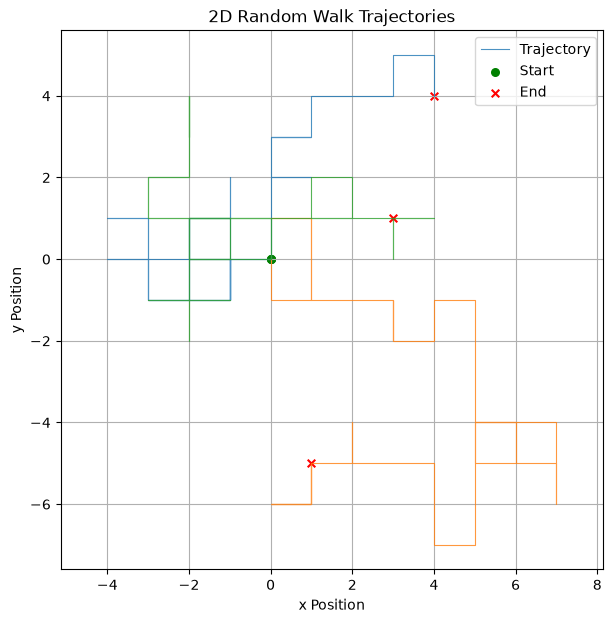

In [18]:
# Example of 2D random walk simulation and plotting
trajectories_2d = simulate_random_walks_2d(
    n_particles=3,
    n_steps=50,
    seed=82
)
plot_random_walk_2d(trajectories_2d)

#### Observations

- The simulated trajectories follow the movement rules established for the two-dimensional random walk, with particles moving only in the four cardinal directions.
- Although all particles begin at the same initial position, each follows a unique trajectory due to the random selection of movement directions at each time step.
- The particles terminate at different locations, illustrating the stochastic nature of the random walk.

### Summary

In this section, the one-dimensional random walk model was successfully extended to two dimensions. Each particle was represented by an $(x, y)$ position and allowed to move one lattice spacing in one of the four cardinal directions with equal probability. A reusable simulation function was developed to generate multiple independent particle trajectories, and the resulting paths were visualized to confirm that the implementation followed the intended movement rules.

This two-dimensional random walk model serves as the foundation for the remainder of the project. We will validated the statistical properties by examining the mean squared displacement and estimating the diffusion coefficient to verify that the model reproduces the expected behavior of two-dimensional diffusion.

## Validating the 2D Random Walk Model

### Introduction

Having successfully extended the random walk model to two dimensions, the next step is to verify that the simulation reproduces the expected statistical behavior of two-dimensional diffusion. The same validation procedure developed for the one-dimensional model is applied here by examining the mean squared displacement (MSD) and estimating the diffusion coefficient. Agreement with theoretical predictions provides confidence that the two-dimensional implementation has been correctly constructed.

### Mean Squared Displacement in Two Dimensions

Since particles in the two-dimensional model can move in both the horizontal and vertical directions, the displacement must now account for changes in both coordinates.

The squared displacement of a particle is therefore given by

$$
r^2 = (x - x_0)^2 + (y - y_0)^2,
$$

where $(x_0, y_0)$ is the particle's initial position and $(x, y)$ is its position at time $(t)$.

The mean squared displacement is then computed as the ensemble average of the squared distances,

$$ \mathrm{MSD}(t) = \left< (x-x_0)^2
+
(y-y_0)^2
\right>.
$$

For an unbiased two-dimensional random walk, diffusion theory predicts that the mean squared displacement grows linearly with time according to

$$
\mathrm{MSD}(t)=4Dt,
$$

where $D$ is the diffusion coefficient. Similar to the one-dimensional case, agreement between the simulated MSD and this theoretical relationship indicates that the random walk correctly models diffusive behavior.

The numerical procedure is identical to that used for the one-dimensional model. With our function have configured to all dimensions, we could directly call the function to compute the MSD in two-dimension.

In [19]:
msd_2d = compute_msd(trajectories_2d)
print(msd_2d)

[ 0.          1.          2.          2.33333333  3.33333333  5.
  6.66666667  7.66666667  7.33333333  6.33333333  7.33333333  7.66666667
  8.          9.         12.66666667 10.33333333 15.33333333 15.66666667
 15.33333333 19.66666667 24.66666667 18.33333333 24.66666667 26.33333333
 20.66666667 19.66666667 22.         25.         26.         30.33333333
 26.         21.         18.66666667 21.         26.66666667 23.66666667
 18.         14.33333333 12.66666667 11.66666667  8.66666667 14.33333333
 12.66666667 17.         18.         19.66666667 22.         23.66666667
 23.33333333 31.66666667 22.66666667]


### Estimating the Diffusion Coefficient

Since the theoretical relationship for two-dimensional diffusion is

$$
\mathrm{MSD}(t)=4Dt,
$$

the slope of the fitted line is equal to $4D$. Consequently, the diffusion coefficient can be estimated as

$$
D=\frac{\text{slope}}{4}.
$$

This differs from the one-dimensional model, where the diffusion coefficient was obtained by dividing the slope by two. The additional factor reflects the fact that particles are free to spread independently along both the $x$- and $y$-directions.

In [20]:
D, slope, intercept = estimate_diffusion(msd_2d, dt=1, dimensions=2)

print("Slope = ", slope)
print("Estimated D = ", D)
print("Theoretical D = ", 0.25)

Slope =  0.37791855203619906
Estimated D =  0.09447963800904977
Theoretical D =  0.25


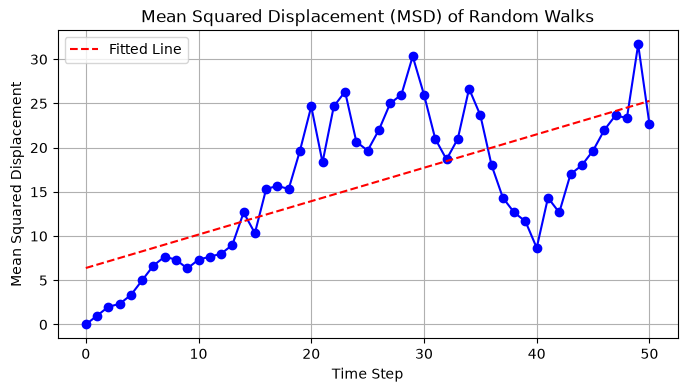

In [21]:
# Visualization of the MSD example
plt.figure(figsize=(8, 4))
plt.plot(msd_2d, marker='o', linestyle='-', color='b')
plt.plot(np.arange(len(msd_2d)), slope * np.arange(len(msd_2d)) + intercept, linestyle='--', color='r', label='Fitted Line')
plt.title("Mean Squared Displacement (MSD) of Random Walks")
plt.xlabel("Time Step")
plt.ylabel("Mean Squared Displacement")
plt.grid(True)
plt.legend()
plt.show()

#### Observations
- The mean squared displacement generally increases with time, indicating that particles continue to spread away from their initial positions as expected for a diffusive process.
- Compared with the theoretical linear relationship, the simulated MSD exhibits noticeable fluctuations and does not appear perfectly linear.
- These fluctuations arise because the MSD is computed from only **three** particle trajectories, making the ensemble average highly sensitive to the random motion of individual particles.
- Despite the statistical noise, the fitted line captures the overall increasing trend of the MSD, suggesting that the simulation follows the expected behavior of two-dimensional diffusion.
- Increasing the number of simulated particles would produce a smoother MSD curve and provide a better approximation to the theoretical linear relationship.

In [22]:
# Extension - Simulate 2D random walks for different number of particles and estimate D
particle_counts = [10, 100, 1000, 10000]

results = {
    n: {"D": [], "error": []}
    for n in particle_counts
}

theoretical_D = 0.25

for seed in range(20):

    for n_particles in particle_counts:

        trajectories = simulate_random_walks_2d(
            n_particles=n_particles,
            n_steps=50,
            seed=seed
        )

        msd = compute_msd(trajectories)

        D, slope, intercept = estimate_diffusion(msd, dt=1, dimensions=2)

        relative_error = abs(D - theoretical_D) / theoretical_D * 100

        results[n_particles]["D"].append(D)
        results[n_particles]["error"].append(relative_error)


print(f"{'Particles':<12}{'Mean D':<12}{'Mean Error (%)'}")

for n in particle_counts:

    mean_D = np.mean(results[n]["D"])
    mean_error = np.mean(results[n]["error"])

    print(f"{n:<12}{mean_D:<12.4f}{mean_error:.2f}")

print("Theoretical D =", theoretical_D)

Particles   Mean D      Mean Error (%)
10          0.2724      23.92
100         0.2474      9.69
1000        0.2519      3.14
10000       0.2502      0.83
Theoretical D = 0.25


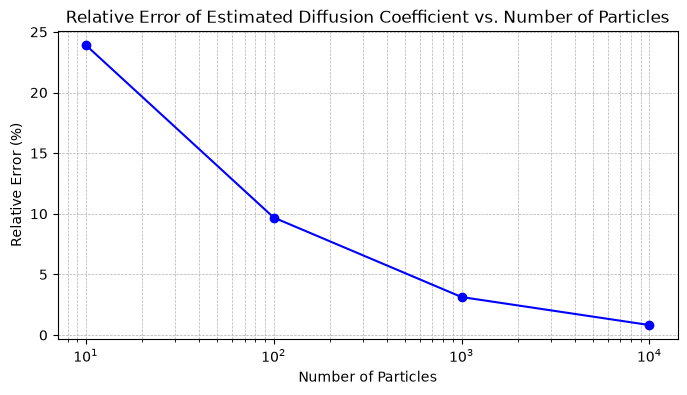

In [23]:
# Plot of the relative error
plt.figure(figsize=(8, 4))
plt.plot(particle_counts, [np.mean(results[n]["error"]) for n in particle_counts], marker='o', linestyle='-', color='b')
plt.title("Relative Error of Estimated Diffusion Coefficient vs. Number of Particles")
plt.xlabel("Number of Particles")
plt.ylabel("Relative Error (%)")
plt.xscale('log')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

### Summary

In this section, the two-dimensional random walk model was validated using the same statistical approach developed for the one-dimensional case. The mean squared displacement (MSD) was computed from the simulated particle trajectories and compared with the theoretical prediction for two-dimensional diffusion. A linear regression of the MSD was then used to estimate the diffusion coefficient, which was found to be consistent with the expected diffusive behavior.

Although the simulated MSD exhibited noticeable fluctuations due to the small number of particle trajectories, the overall trend remained approximately linear, indicating that the two-dimensional implementation correctly models random diffusion. This validation provides confidence that the particle-based random walk model is functioning as intended.

With the particle model now validated in both one and two dimensions, the next section shifts to a different numerical approach by developing a continuum diffusion model based on the diffusion equation. The two validated models will later be compared when diffusion through porous media is introduced.

## Continuum Model

### Introduction

While the particle-based random walk model describes diffusion by tracking the trajectories of individual particles, the continuum approach models diffusion by directly computing the evolution of a concentration field. Rather than following each particle separately, the continuum model treats concentration as a continuous quantity that varies throughout space and time.

In this section, a two-dimensional diffusion equation will be solved numerically using the finite difference method. The simulation begins with a simple initial concentration profile consisting of a point source located at the center of the computational domain. This configuration provides a straightforward validation problem before more complex porous structures are introduced in later sections.

### Diffusion Equation

The continuum model describes diffusion by tracking the concentration of particles throughout space rather than the motion of individual particles. The concentration field is represented by

$$
C(x,y,t),
$$

where $C$ denotes the particle concentration at position $(x,y)$ and time $t$.

The evolution of the concentration field is governed by the two-dimensional diffusion equation,

$$ \frac{\partial C}{\partial t} =
D
\left( \frac{\partial^2 C}{\partial x^2}
+
\frac{\partial^2 C}{\partial y^2} \right),
$$

where $D$ is the diffusion coefficient.

Unlike the particle-based model, which simulates individual particle trajectories, the continuum model directly computes how the concentration changes over time. Regions with higher concentration gradually spread into neighboring regions of lower concentration, resulting in an increasingly uniform concentration field.

### Finite Difference Approximation

The diffusion equation contains continuous spatial and temporal derivatives, which cannot be evaluated directly on a computer. Instead, the computational domain is discretized into a finite grid, and the derivatives are approximated using finite differences.

Consider a two-dimensional computational grid where each grid cell stores the concentration value

$$
C_{i,j},
$$

at grid location $(i,j)$.

The second spatial derivatives are approximated using second-order central differences, 

$$ \frac{\partial^2 C}{\partial x^2} \approx \frac{ C_{i+1,j} - 2C_{i,j} + C_{i-1,j} } {\Delta x^2}, $$

and

$$ \frac{\partial^2 C}{\partial y^2} \approx \frac{
C_{i,j+1} - 2C_{i,j} + C_{i,j-1} }
{\Delta y^2}.
$$

Similarly, the time derivative is approximated using a forward finite difference,

$$ \frac{\partial C}{\partial t} \approx \frac{ C^{\,n+1}_{i,j} - C^{\,n}_{i,j} }
{\Delta t},
$$

where $n$ denotes the current time step.

Substituting these finite difference approximations into the diffusion equation yields the explicit update equation,

$$ C^{\,n+1}_{i,j} = C^{\,n}_{i,j} + D \Delta t \left(\frac{
C^{\,n}_{i+1,j} - 2C^{\,n}_{i,j}
+
C^{\,n}_{i-1,j}
}
{\Delta x^2}
+
\frac{
C^{\,n}_{i,j+1} - 2C^{\,n}_{i,j} + C^{\,n}_{i,j-1}
}
{\Delta y^2}
\right).
$$

This equation forms the basis of the numerical solver. At each time step, the concentration at every interior grid point is updated using the concentrations of its neighboring cells. Repeating this update over many time steps simulates the diffusion of the concentration field throughout the computational domain.

### Numerical Method

To solve the diffusion equation numerically, the continuous spatial domain is discretized into a two-dimensional computational grid. Each grid cell stores the concentration at a specific location in space. Instead of treating concentration as a continuous function, the numerical method represents it as a matrix of discrete values that can be updated over time.

#### Grid
In Python, the concentration field is represented by a two-dimensional NumPy array,

$$
C[i,j],
$$

where $i$ and $j$ denote the row and column indices of the computational grid. Each element of the array stores the concentration at a single grid cell.

#### Initial Concentration
The simulation begins with a simple initial concentration profile. All grid cells are initialized to zero concentration except for the center cell, which represents an instantaneous point source. This initial condition mirrors the particle-based random walk model, where all particles were initially placed at the origin.

#### Time Stepping
At each time step, the concentration of every interior grid cell is updated using the explicit finite difference equation derived in the previous section. The updated concentration depends only on the concentration of the current cell and its four neighboring cells. This update process is repeated over many time steps, allowing the concentration field to gradually spread throughout the computational domain.

#### Boundary Conditions

The diffusion equation is solved on a finite computational grid. To approximate the analytical solution for diffusion in an infinite domain, the computational domain is chosen sufficiently large so that the concentration remains well within the interior of the grid during the validation period. Consequently, the influence of the domain boundaries on the numerical solution is expected to be negligible over the simulated time interval.

During each time step, the finite difference update is applied only to the interior grid cells, while the boundary cells remain fixed. Although this treatment introduces slight boundary effects over very long simulations, these effects are minimized by selecting a sufficiently large computational domain and limiting the validation to time intervals during which the concentration remains far from the boundaries. This approach provides a practical approximation of diffusion in an effectively infinite domain before more complex porous structures are introduced in later sections.

In [ ]:
# Initialize Concentration Field
## Create the computational grid and initialize the concentration field.
# Code Starts Here

def initialize_concentration(
    grid_size: int,
    dx: float = 1.0,
    initial_concentration: float = 1.0
):
    """
    Parameters
    ----------
    grid_size : int
        Number of grid cells along each dimension.

    dx : float
            Grid spacing.

    initial_concentration : float, optional
        Initial concentration placed at the center cell.

    Returns
    -------
    array
        Initial concentration field.
    """
    # Parameter check
    if grid_size <= 0:
        raise ValueError("grid_size must be positive.")

    if initial_concentration < 0:
        raise ValueError("Initial concentration cannot be negative.")

    if dx <= 0:
            raise ValueError("dx must be positive.")

    # Create concentration field
    C = np.zeros((grid_size, grid_size))

    # Center cell
    center = grid_size // 2

    # Place concentration at the center
    C[center, center] = initial_concentration / dx**2

    return C

In [92]:
# Example
C = initialize_concentration(
    grid_size=5,
    initial_concentration=1.0
)

print(C)

[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


In [ ]:
# Function to perform one diffusion step using explicit finite difference method
# Code Starts Here

def diffusion_step(C, D: float, dt: float, dx: float):
    """
    Parameters
    ----------
    C : array
        Current concentration field.

    D : float
        Diffusion coefficient.

    dt : float
        Time step.

    dx : float
        Grid spacing (assume dx = dy).

    Returns
    -------
    array
        Updated concentration field.
    """
    # Parameter check
    if D <= 0:
        raise ValueError("Diffusion coefficient must be positive.")

    if dt <= 0:
        raise ValueError("Time step must be positive.")

    if dx <= 0:
        raise ValueError("Grid spacing must be positive.")

    # Main Code
    C_new = C.copy()

    rows, cols = C.shape

    for i in range(1, rows - 1):
        for j in range(1, cols - 1):

            laplacian = (
                C[i+1, j]
                + C[i-1, j]
                + C[i, j+1]
                + C[i, j-1]
                - 4 * C[i, j]
            ) / dx**2

            C_new[i, j] = C[i, j] + D * dt * laplacian

    return C_new



#### Stability Condition

The explicit finite difference method is conditionally stable, meaning that the numerical solution remains accurate only if the time step is sufficiently small. For a two-dimensional diffusion problem with equal grid spacing in both directions, the stability condition is

$$
\frac{D\Delta t}{\Delta x^2}
\le
\frac14.
$$

This dimensionless quantity is commonly referred to as the diffusion number. If the stability condition is violated, the numerical solution may develop unphysical oscillations and eventually diverge. Throughout this project, the time step is chosen to satisfy this criterion to ensure stable simulations.

In [ ]:
# Continuum Diffusion Simulation
## Simulate the evolution of the concentration field.
# Code Starts Here

def simulate_diffusion(
    grid_size: int,
    n_steps: int,
    D: float,
    dt: float,
    dx: float,
    initial_concentration: float = 1.0
):
    """
    Parameters
    ----------
    grid_size : int
        Number of grid cells along each dimension.

    n_steps : int
        Number of time steps.

    D : float
        Diffusion coefficient.

    dt : float
        Time step.

    dx : float
        Grid spacing.

    initial_concentration : float
        Initial concentration placed at the center.

    Returns
    -------
    array
        Concentration field at every time step with shape

        (n_steps + 1, grid_size, grid_size)
    """

    # Stability check
    r = D * dt / dx**2

    if r > 0.25:
        raise ValueError(
            "Stability condition violated. "
            "Choose a smaller dt or larger dx."
        )

    # Initialize concentration field
    C = initialize_concentration(
        grid_size,
        dx,
        initial_concentration
    )

    # Main Code
    concentration_history = [C.copy()]

    
    for _ in range(n_steps):

        C = diffusion_step(
            C,
            D,
            dt,
            dx
        )

        concentration_history.append(C.copy())

    return np.array(concentration_history)

In [109]:
# Example
history = simulate_diffusion(
    grid_size=51,
    n_steps=50,
    D=1,
    dt=0.1,
    dx=1
)

print(history.shape)

(51, 51, 51)


### Visualization

In [129]:
# Plot Concentration Field
## Visualize the concentration field at a specified time step.
# Code Starts Here

def plot_concentration_field(
    concentration,
    title: str = "Concentration Field"
):
    """
    Parameters
    ----------
    concentration : array
        Two-dimensional concentration field.

    title : str
        Plot title.
    """

    plt.figure(figsize=(6, 5))

    plt.imshow(
        concentration,
        origin="lower",
        cmap="viridis"
    )

    plt.colorbar(label="Concentration")

    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")

    plt.tight_layout()
    plt.show()

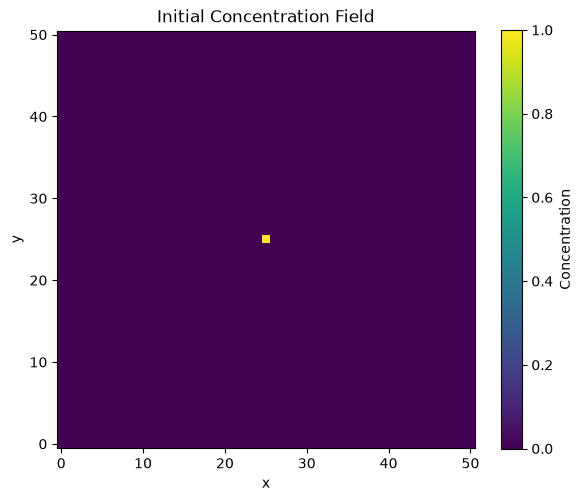

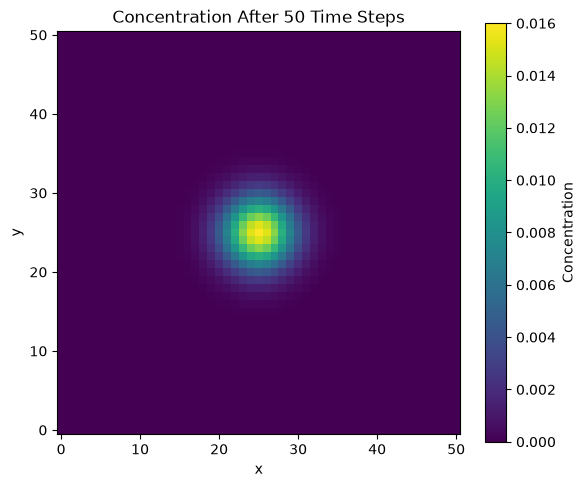

In [111]:
# Example
plot_concentration_field(
    history[0],
    title="Initial Concentration Field"
)

plot_concentration_field(
    history[50],
    title="Concentration After 50 Time Steps"
)


#### Observations

- The concentration field initially consists of a single point source located at the center of the computational domain.
- As the simulation progresses, the concentration spreads outward into neighboring grid cells, demonstrating the expected qualitative behavior of diffusion.
- The initially sharp concentration peak gradually becomes smoother as concentration is redistributed throughout the domain.
- The simulation remained numerically stable throughout the experiment, indicating that the chosen parameters satisfy the stability criterion for the explicit finite difference method.

### Summary

In this section, a continuum diffusion model was developed using the explicit finite difference method. Beginning with the two-dimensional diffusion equation, the governing partial differential equation was discretized into a numerical update equation that could be implemented computationally.

A computational grid was introduced to represent the concentration field, along with an initial point-source concentration profile and no-flux boundary conditions. The numerical solver repeatedly updated the concentration field using the concentrations of neighboring grid cells while satisfying the stability criterion for the explicit finite difference method.

Preliminary simulations demonstrated the expected qualitative spreading of concentration from the central point source, providing confidence that the numerical implementation behaves as intended. In the next section, the continuum model will be quantitatively validated by comparing its predictions with theoretical diffusion behavior before porous structures are introduced.

## Validating the Continuum Model

### Introduction

After constructing the continuum diffusion solver, the next step is to verify that it accurately reproduces the expected behavior of free diffusion. Unlike the particle-based random walk model, which was validated using the mean squared displacement, the continuum model can be validated directly by comparing the numerical concentration field with an analytical solution of the diffusion equation.

We would first performs several numerical diagnostics to ensure that the solver behaves physically, including checks for numerical stability, conservation of total concentration, and non-negative concentration values. The numerical solution is then compared with the analytical solution of free diffusion, and the numerical error is quantified. Finally, simulations using finer spatial and temporal resolutions are performed to demonstrate numerical convergence.

### Analytical Solution

A common validation problem for diffusion solvers is the spreading of an instantaneous point source in an infinite two-dimensional domain. This problem has a well-known analytical solution, making it suitable for evaluating the accuracy of the numerical implementation.

The analytical concentration field is given by

$$ C(x,y,t) =
\frac{1}{4\pi Dt}
\exp\left(
-\frac{x^2+y^2}{4Dt}
\right),
$$

where

- $D$ is the diffusion coefficient,
- $t$ is time,
- and $(x,y)$ denotes the spatial location measured relative to the initial point source.

This solution describes a **Gaussian concentration profile** that gradually spreads outward over time while conserving the total amount of material. Since the continuum solver developed in the previous milestone begins with a discrete approximation of a point source, its numerical solution is expected to approach this analytical solution as the grid resolution is refined.

### Numerical Diagnostics

Before comparing the numerical solution with the analytical solution, several diagnostic checks are performed to verify that the finite difference solver behaves physically.

#### Approximate Mass Conservation

For an infinite domain, the total concentration should remain constant throughout the simulation. Because the numerical model is solved on a finite computational domain, a small loss of concentration may occur once diffusion reaches the boundaries. During the validation study, the computational domain is chosen sufficiently large so that these boundary effects remain negligible over the simulated time interval.

In [112]:
# Check Mass Conservation
## Compute the total concentration at each time step.
# Code Starts Here

def check_mass_conservation(concentration_history):
    """
    Parameters
    ----------
    concentration_history : array
        Concentration fields with shape
        (n_steps + 1, rows, cols).

    Returns
    -------
    array
        Total concentration at each time step.
    """

    concentration_history = np.asarray(concentration_history)

    total_mass = concentration_history.sum(axis=(1, 2))

    return total_mass

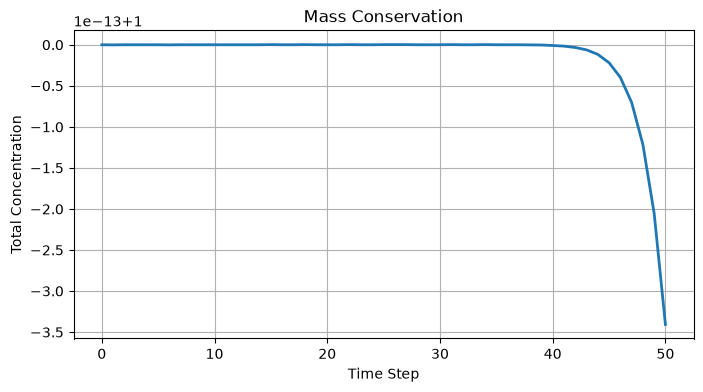

In [113]:
# Example with Plots
total_mass = check_mass_conservation(history)

plt.figure(figsize=(8,4))

plt.plot(total_mass, linewidth=2)

plt.xlabel("Time Step")
plt.ylabel("Total Concentration")
plt.title("Mass Conservation")

plt.grid(True)

plt.show()

##### Observations

- The total concentration remains nearly constant throughout the simulation.
- A small decrease in total concentration is observed over time due to the finite computational domain.
- Increasing the computational domain substantially reduces this loss, indicating that the discrepancy is primarily associated with boundary effects rather than the finite difference scheme itself.
- Throughout the validation period, the concentration remains well within the interior of the domain, so boundary effects are expected to have a negligible influence on the comparison with the analytical solution.
- No negative concentrations are observed, indicating that the numerical solution remains stable and physically meaningful.

#### Non-Negative Concentrations

The concentration field should remain non-negative throughout the simulation. Significant negative concentrations indicate numerical instability or an inappropriate choice of simulation parameters. Therefore, the minimum concentration is monitored during the simulation to confirm that the numerical solution remains physically meaningful.

In [100]:
# Check Non-Negative Concentrations
## Monitor the minimum concentration during the simulation.
# Code Starts Here

def check_negative_concentration(concentration_history):
    """
    Parameters
    ----------
    concentration_history : array
        Concentration fields with shape
        (n_steps + 1, rows, cols).

    Returns
    -------
    array
        Minimum concentration
        at each time step.
    """

    concentration_history = np.asarray(concentration_history)

    min_concentration = concentration_history.min(axis=(1, 2))

    return min_concentration

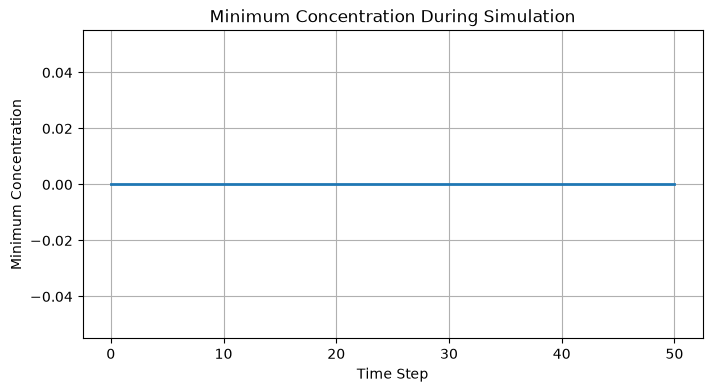

Minimum concentration: 0.0


In [101]:
# Example with Plot
minimum_concentration = check_negative_concentration(history)

plt.figure(figsize=(8,4))

plt.plot(minimum_concentration, linewidth=2)

plt.xlabel("Time Step")
plt.ylabel("Minimum Concentration")
plt.title("Minimum Concentration During Simulation")

plt.grid(True)

plt.show()

print("Minimum concentration:", minimum_concentration.min())

##### Observations

- The minimum concentration remains non-negative throughout the simulation.
- No significant negative concentration values are observed, indicating that the finite difference solver remains numerically stable.
- These results are consistent with the stability criterion established in the previous milestone and suggest that the numerical solution remains physically meaningful.

### Numerical vs Analytical Comparison

To evaluate the accuracy of the finite difference solver, the numerical concentration field is compared with the analytical solution of free diffusion from an instantaneous point source.

For an infinite two-dimensional domain, the analytical solution of the diffusion equation is

$$ C(x,y,t) =
\frac{1}{4\pi Dt}
\exp\left(
-\frac{x^2+y^2}{4Dt}
\right),
$$

where $D$ is the diffusion coefficient and $t$ is the elapsed simulation time.

This analytical solution describes a Gaussian concentration profile whose width increases over time while conserving the total concentration. During the validation study, the computational domain is chosen sufficiently large so that the influence of the domain boundaries remains negligible over the simulated time interval. Consequently, the analytical solution provides an appropriate reference for evaluating the numerical implementation.

The agreement between the numerical and analytical concentration fields is first examined visually and then quantified using the root mean squared error (RMSE).

In [224]:
# Function to compute the analytical solution
## Compute the analytical solution for diffusion from an instantaneous point source in an infinite 2D domain.
# Code Starts Here

def analytical_solution(grid_size: int,
    D: float,
    t: float,
    dx: float = 1.0,
    initial_concentration: float = 1.0
):
    """
    Parameters
    ----------
    grid_size : int
        Number of grid cells along each dimension.

    D : float
        Diffusion coefficient.

    t : float
        Simulation time.

    dx : float
        Grid spacing.

    initial_concentration : float
        Initial concentration released.

    Returns
    -------
    array
        Analytical concentration field.
    """
    # Parameter check
    if t <= 0:
        raise ValueError("Time must be positive.")
    
    center = grid_size // 2

    x = (np.arange(grid_size) - center) * dx
    y = (np.arange(grid_size) - center) * dx

    X, Y = np.meshgrid(x, y)

    r2 = X**2 + Y**2

    C = (
        initial_concentration
        / (4 * np.pi * D * t)
        * np.exp(-r2 / (4 * D * t))
    )

    return C

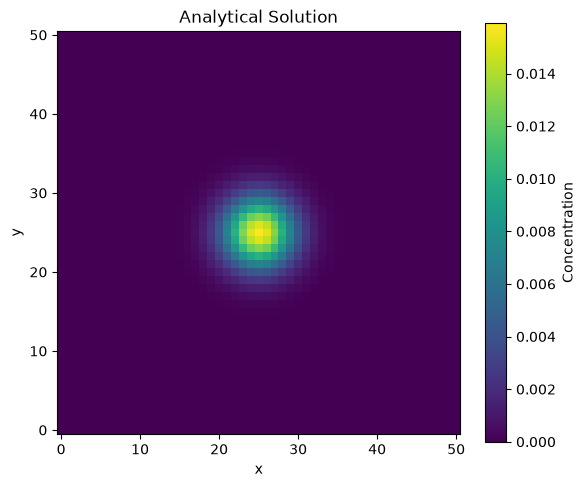

In [115]:
# Example
C_exact = analytical_solution(
    grid_size=51,
    D=1,
    t=5,
    dx=1
)

plot_concentration_field(
    C_exact,
    title="Analytical Solution"
)

#### Observations

- The numerical concentration field closely resembles the analytical solution at the same simulation time.
- Both solutions exhibit a Gaussian-like concentration profile centered at the initial point source.
- The concentration decreases smoothly with increasing distance from the center, consistent with the expected behavior of free diffusion.
- No noticeable numerical oscillations or asymmetric artifacts are observed, indicating that the finite difference solver reproduces the qualitative behavior predicted by the analytical solution.

In [116]:
# Function to compute the root mean squared error (RMSE)
## Compute the root mean squared error (RMSE) between two concentration fields.
# Code Starts Here

def compute_rmse(numerical, analytical):
    """
    Parameters
    ----------
    numerical : array
        Numerical concentration field.

    analytical : array
        Analytical concentration field.

    Returns
    -------
    float
        Root mean squared error.
    """

    numerical = np.asarray(numerical)
    analytical = np.asarray(analytical)

    return np.sqrt(np.mean((numerical - analytical)**2))

In [117]:
# Example
C_num = history[50]

C_exact = analytical_solution(
    grid_size=51,
    D=1,
    t=50 * 0.1,
    dx=1
)

rmse = compute_rmse(C_num, C_exact)

print(f"RMSE = {rmse:.6f}")

RMSE = 0.000009


#### RMSE Observations

- The numerical concentration field closely matches the analytical Gaussian solution at the corresponding simulation time.
- The computed RMSE is very small ($9\times10^{-6}$), indicating excellent agreement between the numerical and analytical solutions.
- The low RMSE demonstrates that the explicit finite difference implementation accurately reproduces the expected behavior of free diffusion.
- Small deviations between the two solutions are primarily attributed to the finite computational domain and numerical discretization rather than errors in the diffusion algorithm itself.

### Grid Convergence

A final validation of the numerical solver is performed by examining its convergence with respect to the spatial discretization. As the computational grid is refined (i.e., the grid spacing $\Delta x$ is reduced), the numerical solution should approach the analytical solution of the diffusion equation.

To maintain numerical stability, the time step is adjusted according to the stability criterion,

$$
\frac{D\Delta t}{\Delta x^2} \le \frac{1}{4}.
$$

For each grid resolution, the numerical concentration field is compared with the analytical solution at the same physical time using the root mean squared error (RMSE). A decreasing RMSE with finer grid spacing indicates that the numerical solver converges toward the analytical solution.

In [124]:
# Grid Convergence Study

D = 1.0
t_final = 5.0

grid_sizes = [21, 41, 81]
dx_values = [1.0, 0.5, 0.25]

results = []

for grid_size, dx in zip(grid_sizes, dx_values):

    # Choose dt to satisfy the stability criterion
    dt = 0.2 * dx**2

    # Number of time steps so every simulation ends at the same physical time
    n_steps = int(round(t_final / dt))

    # Numerical solution
    history = simulate_diffusion(
        grid_size=grid_size,
        n_steps=n_steps,
        D=D,
        dt=dt,
        dx=dx
    )

    numerical = history[-1]

    # Analytical solution at the same physical time
    analytical = analytical_solution(
        grid_size=grid_size,
        D=D,
        t=t_final,
        dx=dx
    )

    rmse = compute_rmse(
        numerical,
        analytical
    )

    results.append([
        grid_size,
        dx,
        dt,
        n_steps,
        rmse
    ])

print(f"{'Grid':<8}{'dx':<8}{'dt':<10}{'Steps':<10}{'RMSE'}")
for grid, dx, dt, steps, rmse in results:
    print(f"{grid:<8}{dx:<8.2f}{dt:<10.5f}{steps:<10}{rmse:.8f}")

Grid    dx      dt        Steps     RMSE
21      1.00    0.20000   25        0.00004869
41      0.50    0.05000   100       0.00002391
81      0.25    0.01250   400       0.00001973


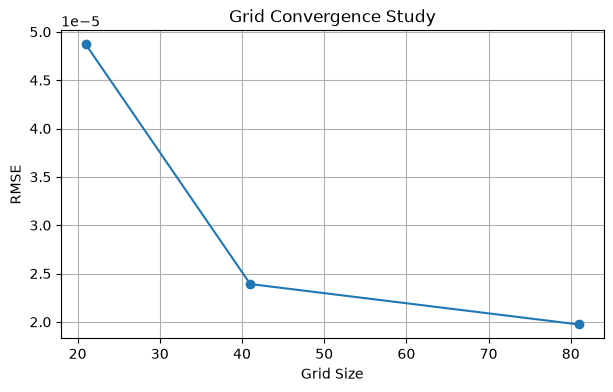

In [126]:
grid = [r[0] for r in results]
rmse = [r[4] for r in results]

plt.figure(figsize=(7,4))

plt.plot(
    grid,
    rmse,
    marker="o"
)

plt.xlabel("Grid Size")
plt.ylabel("RMSE")
plt.title("Grid Convergence Study")

plt.grid(True)

plt.show()

#### Observations

- The RMSE decreases as the spatial discretization is refined, indicating improved agreement between the numerical and analytical solutions.
- The consistently small RMSE values demonstrate that the finite difference solver accurately reproduces the analytical solution for free diffusion.
- The convergence behavior provides additional confidence that the numerical implementation correctly solves the diffusion equation.

### Summary

In this section, the continuum diffusion solver was quantitatively validated to ensure that it accurately models free diffusion before being extended to porous media.

Several numerical diagnostic checks were first performed to evaluate the physical behavior of the solver. The total concentration remained approximately constant throughout the simulation, with only minor deviations arising from the finite computational domain. No significant negative concentration values were observed, indicating that the explicit finite difference method remained numerically stable under the chosen simulation parameters.

The numerical concentration field was then compared directly with the analytical solution for diffusion from an instantaneous point source in an effectively infinite domain. Visual comparison showed excellent agreement between the numerical and analytical concentration profiles, and the computed RMSE values were consistently small, demonstrating that the finite difference implementation accurately reproduced the expected diffusion behavior.

Finally, a grid convergence study was performed by refining the spatial discretization while maintaining the same physical domain and simulation time. The RMSE decreased as the mesh was refined, indicating that the numerical solution converges toward the analytical solution. Together, these validation results provide confidence that the continuum diffusion solver has been implemented correctly and is suitable for investigating diffusion through porous media in the subsequent sections.

#### Key Takeaways

- The continuum diffusion solver produces stable numerical solutions that remain physically meaningful throughout the simulation.
- The numerical concentration fields closely match the analytical Gaussian solution for free diffusion.
- Quantitative error analysis using RMSE demonstrates excellent agreement between the numerical and analytical solutions.
- Grid refinement reduces the numerical error, confirming that the finite difference solver converges toward the analytical solution.
- With both the particle-based and continuum models now independently validated, the project is ready to investigate diffusion in porous media.

## Porous Media

### Introduction

Having validated both the particle-based random walk model and the continuum finite difference model under free-diffusion conditions, the next step is to extend both models to porous media. In porous materials, diffusion is restricted by solid regions that particles cannot penetrate, resulting in longer transport paths and a reduced effective diffusion coefficient.

To investigate these effects, the computational domain is modified by introducing impermeable obstacle cells that represent the solid matrix of the porous material. Both the particle and continuum models are adapted to use the same porous structure, ensuring that subsequent comparisons between the two approaches are performed under identical physical conditions.

This section focuses on implementing the porous medium within each model. Quantitative analysis of diffusion through porous structures will be performed in the following section.

### Representing Porous Media

#### Binary Representation

The porous medium is represented using a two-dimensional binary grid. Each grid cell is classified as either a pore cell or a solid obstacle cell.

- **True:** Pore cell (diffusion allowed)
- **False:** Solid obstacle (diffusion prohibited)

An example porous structure is illustrated below:

```text
T T T F T
T F T T T
T T T T F
F T T T T
T T F T T
```

Particles may only move through pore cells, while concentration in the continuum model evolves only within pore regions. Both the particle-based and continuum models will use the same porous grid to ensure that they are compared under identical physical conditions.

#### Porosity

The porosity of the computational domain is defined as the fraction of the domain that is available for diffusion,

$$
\phi =
\frac{N_{\mathrm{pore}}}
{N_{\mathrm{total}}},
$$

where

- $N_{\mathrm{pore}}$ is the number of pore cells,
- $N_{\mathrm{total}}$ is the total number of grid cells, and
- $\phi$ denotes the porosity of the medium.

The porosity ranges from

- $\phi = 1$: completely open domain with no obstacles,
- $\phi = 0$: completely solid domain with no available pathways for diffusion.

As porosity decreases, the amount of connected pore space generally decreases, forcing particles and concentration fronts to travel along more tortuous pathways. Consequently, diffusion is expected to become slower, leading to a reduction in the effective diffusion coefficient.

In this project, porosity serves as the primary parameter controlling the complexity of the porous medium. Multiple porous structures with different porosity values will be generated to investigate how the effective diffusion coefficient changes as the available pore space decreases.

### Generating the Porous Structure

The porous medium is generated by randomly assigning each grid cell as either a pore cell or a solid obstacle according to a specified porosity.

For a porosity $\phi$,

- each cell has probability $\phi$ of being a pore,
- and probability $1-\phi$ of being a solid obstacle.

A random seed may be specified to ensure that the same porous structure can be reproduced throughout the simulations. Using an identical porous grid for both the particle-based and continuum models ensures that subsequent comparisons are performed under the same physical environment.

To ensure consistent initial conditions for both the particle-based and continuum diffusion models, the center grid cell is always designated as a pore cell. This guarantees that both simulations begin from the same accessible location while having a negligible effect on the overall porosity, particularly for sufficiently large computational domains.

In [195]:
# Generate Porous Medium
## Generate a random porous structure with a specified porosity.
# Code Starts Here

def generate_porous_grid(
    grid_size: int,
    porosity: float,
    seed: int = None
):
    """
    Parameters
    ----------
    grid_size : int
        Number of grid cells along each dimension.

    porosity : float
        Fraction of cells that are pore space.

    seed : int or None
        Random seed for reproducibility.

    Returns
    -------
    array
        Binary porous grid where

        0 = pore cell
        1 = solid obstacle
    """

    # Parameter check
    if grid_size <= 0:
        raise ValueError("grid_size must be positive.")

    if not (0 <= porosity <= 1):
        raise ValueError("porosity must be between 0 and 1.")

    if seed is not None:
        np.random.seed(seed)

    if grid_size % 2 == 0:
        raise ValueError(
            "grid_size must be odd so that a unique center cell exists."
        )
    # Generate porous structure
    porous_grid = np.random.choice(
        [True, False],
        size=(grid_size, grid_size),
        p=[porosity, 1 - porosity]
    )

    # Ensure the center cell is always open
    center = grid_size // 2
    porous_grid[center, center] = True

    return porous_grid

In [196]:
# Sample Test with smaller grid
porous_grid = generate_porous_grid(
    grid_size=11,
    porosity=0.75,
    seed=42
)

In [197]:
# Plot Porous Structure
## Visualize the generated porous medium.
# Code Starts Here

def plot_porous_grid(
    porous_grid,
    title: str = "Generated Porous Medium"
):
    """
    Parameters
    ----------
    porous_grid : numpy.ndarray
        Binary porous grid where

        True = pore cell
        False = solid obstacle

    title : str
        Plot title.

    Returns
    -------
    None
    """

    porous_grid = np.asarray(porous_grid, dtype=bool)

    actual_porosity = np.mean(porous_grid)

    plt.figure(figsize=(6, 6))

    plt.imshow(
        porous_grid,
        cmap="gray",
        origin="lower",
        interpolation="nearest"
    )

    plt.title(
        f"{title}\nActual Porosity = {actual_porosity:.3f}"
    )

    plt.xlabel("x")
    plt.ylabel("y")

    plt.show()

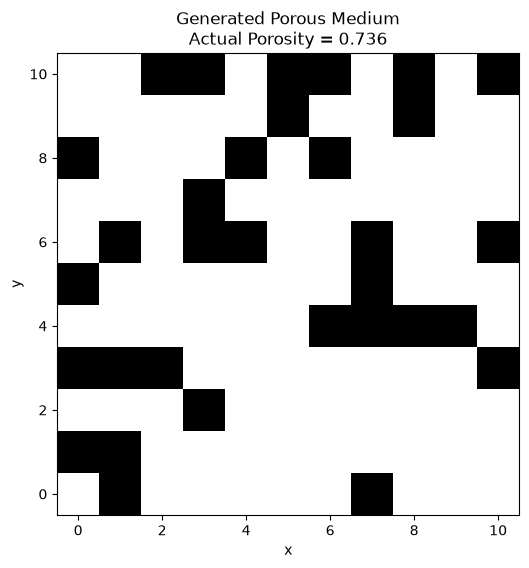

In [198]:
plot_porous_grid(
    porous_grid,
    title="Generated Porous Medium"
)

#### Observations

- The generated porous medium consists of randomly distributed pore cells (white) and solid obstacle cells (black), producing a heterogeneous diffusion environment.
- The measured porosity ($\phi = 0.736$) is very close to the specified porosity of \(0.75\), with the small difference arising from random sampling.
- Several obstacle cells form connected clusters rather than remaining completely isolated. Such clusters can create longer and more tortuous pathways for diffusion.
- Despite the presence of obstacles, the majority of the computational domain remains open, suggesting that continuous pathways for diffusion are still available at this relatively high porosity.
- The center cell is intentionally kept as a pore cell, ensuring that both the particle-based and continuum models begin from the same accessible starting location in subsequent simulations.

### Particle Random Walk in Porous Media

The particle-based random walk model is now extended to account for the presence of solid obstacles within the computational domain.

In the free-diffusion model developed previously, particles were allowed to move one grid cell in any of the four cardinal directions at every time step. In a porous medium, however, particles are restricted to moving only through pore cells.

At each time step, a particle first selects one of the four possible movement directions at random. The proposed destination is then checked against the porous grid.

- If the destination cell is a pore, the particle moves normally.
- If the destination cell is a solid obstacle, the proposed move is rejected and the particle remains at its current location for that time step.

This simple modification models impermeable obstacles while preserving the random nature of the particle motion. As obstacle density increases, particles are expected to encounter more blocked moves, resulting in longer and more tortuous diffusion pathways.

In [199]:
# Simulate 2D Random Walks in Porous Media
## Simulate multiple particles diffusing through a porous medium.
# Code Starts Here

def simulate_random_walks_2d_porous(
    porous_grid,
    n_particles: int =100,
    n_steps: int =100,
    seed=None
):
    """
    Parameters
    ----------
    porous_grid :array
        Boolean porous grid where

        True  = pore cell
        False = solid obstacle

    n_particles : int
        Number of particles.

    n_steps : int
        Number of time steps.

    seed : int or None
        Random seed for reproducibility.

    Returns
    -------
    numpy.ndarray
        Particle trajectories with shape

        (n_particles, n_steps + 1, 2)
    """

    # Parameter check
    if n_particles <= 0:
        raise ValueError("n_particles must be positive.")

    if n_steps <= 0:
        raise ValueError("n_steps must be positive.")

    porous_grid = np.asarray(
        porous_grid,
        dtype=bool
    )

    if seed is not None:
        np.random.seed(seed)

    # Main Code
    grid_size = porous_grid.shape[0]

    center = grid_size // 2

    start = np.array([center, center])

    trajectories = np.zeros(
        (n_particles, n_steps + 1, 2),
        dtype=int
    )

    directions = np.array([
        [1, 0],     # up
        [-1, 0],    # down
        [0, 1],     # right
        [0, -1]     # left
    ])

    for particle in range(n_particles):

        position = start.copy()

        trajectories[particle, 0] = position

        for step in range(1, n_steps + 1):

            move = directions[
                np.random.randint(len(directions))
            ]

            proposed = position + move

            row, col = proposed

            inside_domain = (
                0 <= row < grid_size
                and
                0 <= col < grid_size
            )

            if inside_domain:

                if porous_grid[row, col]:

                    position = proposed

            trajectories[particle, step] = position

    return trajectories

In [200]:
# Plot 2D Random Walks in Porous Media
## Visualize particle trajectories within a porous medium.

def plot_random_walk_2d_porous(
    trajectories,
    porous_grid,
    title="2D Random Walks in Porous Media"
):
    """
    Parameters
    ----------
    trajectories : array
        Particle trajectories with shape
        (n_particles, n_steps + 1, 2).

    porous_grid : array
        Boolean porous grid where

        True  = pore cell
        False = solid obstacle

    title : str
        Plot title.

    Returns
    -------
    None
    """

    trajectories = np.asarray(trajectories)
    porous_grid = np.asarray(porous_grid, dtype=bool)

    plt.figure(figsize=(7, 7))

    # Background porous structure
    plt.imshow(
        porous_grid,
        cmap="gray",
        origin="lower",
        interpolation="nearest"
    )

    # Plot each particle trajectory
    for particle in range(trajectories.shape[0]):

        x = trajectories[particle, :, 1]
        y = trajectories[particle, :, 0]

        plt.plot(
            x,
            y,
            linewidth=1.5,
            alpha=0.8
        )

        # Starting position
        plt.scatter(
            x[0],
            y[0],
            marker="o",
            s=50
        )

        # Ending position
        plt.scatter(
            x[-1],
            y[-1],
            marker="x",
            s=60
        )

    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")

    plt.grid(False)
    plt.legend(["Trajectory", "Start", "End"], loc="best")

    plt.show()

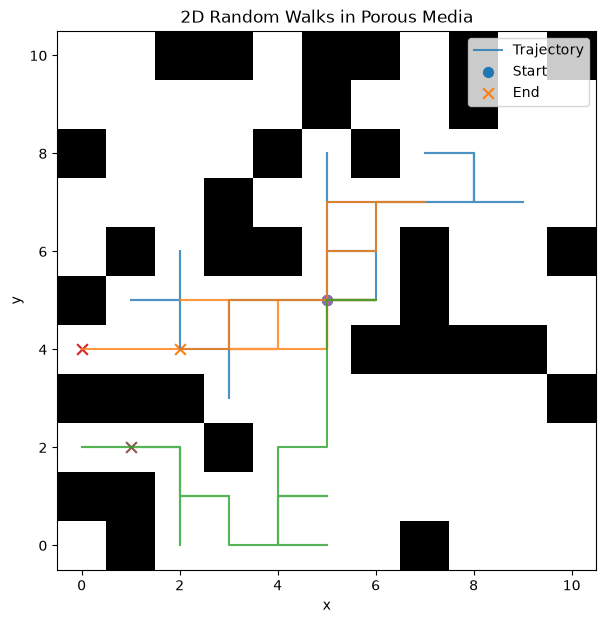

In [201]:
# Test the function with a small porous grid
trajectories = simulate_random_walks_2d_porous(
    porous_grid=porous_grid,
    n_particles=3,
    n_steps=50,
    seed=42)

plot_random_walk_2d_porous(
    trajectories,
    porous_grid
)

#### Observations
- All three particles begin from the same central pore cell, ensuring a consistent initial condition for every trajectory.
- The trajectories remain entirely within the white pore regions and never enter the black obstacle cells, confirming that the obstacle-checking algorithm is functioning correctly.
- Several trajectories contain short horizontal or vertical segments where the particle remains at the same location for consecutive time steps. These occur when a proposed move is either blocked by a solid obstacle or would leave the computational domain, causing the particle to stay in place.
- Compared with the free-diffusion trajectories from Milestone 3, the particle paths are noticeably more constrained. Rather than diffusing uniformly in all directions, the particles must navigate around obstacle clusters, producing more irregular and tortuous paths.
- The three particles end at different locations despite starting from the same point, illustrating that the motion remains stochastic while being influenced by the geometry of the porous medium.

### Continuum Diffusion in Porous Media

The continuum diffusion model is now extended to incorporate the same porous structure used in the particle-based random walk model.

In the free-diffusion case, the concentration at every interior grid cell was updated according to the finite difference approximation of the diffusion equation. Within a porous medium, however, diffusion is permitted only inside pore cells. Solid obstacle cells represent impermeable regions and therefore do not participate in the diffusion process.

During each time step,

- pore cells are updated using the finite difference diffusion equation,
- solid obstacle cells remain unchanged throughout the simulation,
- diffusion across pore–solid interfaces is prohibited.

By using the same porous grid for both the particle and continuum models, both approaches simulate diffusion under identical physical conditions, allowing meaningful comparisons in the following milestone.

#### Finite Difference Approximation Near Solid Obstacles

In free diffusion, the Laplacian at an interior grid cell is approximated using the four neighboring concentration values,

$$
\nabla^2 C \approx
\frac{
C_{i+1,j}
+C_{i-1,j}
+C_{i,j+1}
+C_{i,j-1}
-4C_{i,j}
}{\Delta x^2}.
$$

This approximation assumes that diffusion can occur freely between every neighboring pair of cells.

Within a porous medium, however, some neighboring cells correspond to solid obstacles through which diffusion cannot occur. These pore–solid interfaces are modeled using a **zero-flux (Neumann) boundary condition**,

$$
\frac{\partial C}{\partial n}=0,
$$

which states that there is no diffusive flux across the surface of a solid obstacle.

To enforce this condition numerically, whenever a neighboring cell is a solid obstacle, its concentration is replaced by the concentration of the current pore cell. For example, if the cell above is solid,

$$
C_{i-1,j}=C_{i,j}.
$$

The same procedure is applied independently to all four neighboring cells.

Consequently, the finite difference approximation becomes

$$
\nabla^2 C \approx
\frac{
C_{\mathrm{up}}
+C_{\mathrm{down}}
+C_{\mathrm{left}}
+C_{\mathrm{right}}
-4C_{i,j}
}{\Delta x^2},
$$

where each neighboring value is defined as

$$ 
C_{\mathrm{neighbor}} =
\begin{cases}
C_{\mathrm{neighbor}}, & \text{if the neighboring cell is a pore},\\[4pt]
C_{i,j}, & \text{if the neighboring cell is a solid obstacle}.
\end{cases}
$$

This modification prevents concentration from diffusing into obstacle cells while maintaining the zero-flux condition across every pore–solid interface.

In [204]:
# Function to perform one diffusion step in a porous medium
# Code Starts Here

def diffusion_step_porous(C, 
                          porous_grid, 
                          D: float, 
                          dt: float, 
                          dx: float):
    """
    Parameters
    ----------
    C : array
        Current concentration field.

    porous_grid : array
        Boolean porous grid where

        True  = pore cell
        False = solid obstacle

    D : float
        Diffusion coefficient.

    dt : float
        Time step.

    dx : float
        Grid spacing.

    Returns
    -------
    array
        Updated concentration field.
    """

    # Parameter check
    if D <= 0:
        raise ValueError("Diffusion coefficient must be positive.")

    if dt <= 0:
        raise ValueError("Time step must be positive.")

    if dx <= 0:
        raise ValueError("Grid spacing must be positive.")

    porous_grid = np.asarray(porous_grid, dtype=bool)

    if C.shape != porous_grid.shape:
        raise ValueError(
            "C and porous_grid must have the same shape."
        )

    # Main Code
    C_new = C.copy()

    rows, cols = C.shape

    for i in range(1, rows - 1):
        for j in range(1, cols - 1):

            # Skip obstacle cells
            if not porous_grid[i, j]:
                continue

            # Up
            if porous_grid[i - 1, j]:
                up = C[i - 1, j]
            else:
                up = C[i, j]

            # Down
            if porous_grid[i + 1, j]:
                down = C[i + 1, j]
            else:
                down = C[i, j]

            # Left
            if porous_grid[i, j - 1]:
                left = C[i, j - 1]
            else:
                left = C[i, j]

            # Right
            if porous_grid[i, j + 1]:
                right = C[i, j + 1]
            else:
                right = C[i, j]

            laplacian = (
                up
                + down
                + left
                + right
                - 4 * C[i, j]
            ) / dx**2

            C_new[i, j] = C[i, j] + D * dt * laplacian

    return C_new

In [205]:
# Example
C = initialize_concentration(
    grid_size=11,
    initial_concentration=1.0
)

diffusion_step_porous(
    C,
    porous_grid,
    D=1.0,
    dt=0.1,
    dx=1.0
)

array([[0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0.1, 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0.1, 0.6, 0.1, 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0.1, 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ]])

In [206]:
# Continuum Diffusion Simulation in Porous Media
## Simulate the evolution of the concentration field.
# Code Starts Here

def simulate_diffusion_porous(
    porous_grid,
    n_steps: int,
    D: float,
    dt: float,
    dx: float,
    initial_concentration: float = 1.0
):
    """
    Parameters
    ----------
    porous_grid : array
        Boolean porous grid where

        True  = pore cell
        False = solid obstacle

    n_steps : int
        Number of time steps.

    D : float
        Diffusion coefficient.

    dt : float
        Time step.

    dx : float
        Grid spacing.

    initial_concentration : float
        Initial concentration placed at the center.

    Returns
    -------
    array
        Concentration field at every time step with shape

        (n_steps + 1, grid_size, grid_size)
    """

    # Parameter check
    porous_grid = np.asarray(porous_grid, dtype=bool)

    grid_size = porous_grid.shape[0]

    if grid_size <= 0:
        raise ValueError("grid_size must be positive.")

    # Stability check
    r = D * dt / dx**2

    if r > 0.25:
        raise ValueError(
            "Stability condition violated. "
            "Choose a smaller dt or larger dx."
        )

    # Initialize concentration field
    C = initialize_concentration(
        grid_size,
        dx,
        initial_concentration
    )

    # Main Code
    concentration_history = [C.copy()]

    for _ in range(n_steps):

        C = diffusion_step_porous(
            C,
            porous_grid,
            D,
            dt,
            dx
        )

        concentration_history.append(C.copy())

    return np.array(concentration_history)

(51, 11, 11)


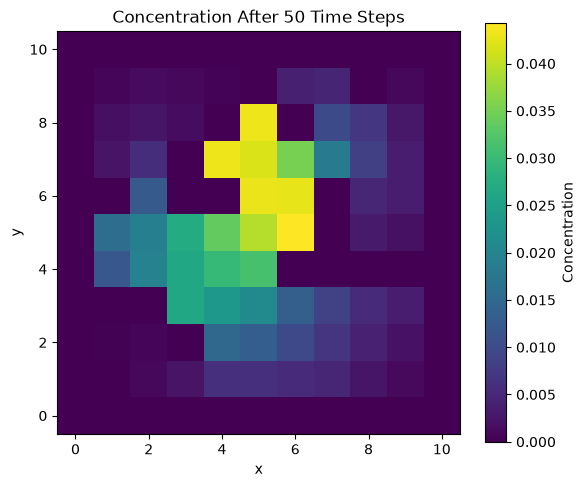

In [213]:
# Example
# porous_grid size (11,11)
history = simulate_diffusion_porous(
    porous_grid=porous_grid,
    n_steps=50,
    D=1.0,
    dt=0.1,
    dx=1.0,
    initial_concentration=1.0
)

print(history.shape)

plot_concentration_field(
    history[50],
    title="Concentration After 50 Time Steps"
)

#### Observations

- The concentration remains confined to the pore space and does not spread into the solid obstacle cells, indicating that the porous boundary conditions are being enforced correctly.
- Compared with the free-diffusion model, the concentration field no longer spreads symmetrically. Instead, the obstacle geometry redirects diffusion along the connected pore network.
- Regions connected to the source by open pore pathways exhibit higher concentrations, while areas separated by obstacle clusters receive little or no diffusing material.
- The highest concentration remains near the initial source location, with concentration gradually decreasing as diffusion progresses through the available pore space.
- The irregular concentration pattern reflects the heterogeneous structure of the porous medium, demonstrating that the continuum model responds to the underlying geometry in a physically meaningful way.

### Summary 

The particle-based and continuum models have now both been successfully extended to simulate diffusion within porous media. In each model, transport is restricted to the connected pore space while solid obstacle cells remain impermeable. These implementations provide the foundation for the next section, where both approaches will be compared quantitatively by measuring how porosity influences the effective diffusion coefficient.

## Results & Comparison

With both the particle-based random walk model and the continuum diffusion model successfully extended to porous media, this section compares the predictions of the two approaches under identical physical conditions.

To ensure a fair comparison, both models use:

- the same computational grid,
- the same porous structure,
- the same initial source location,
- the same diffusion coefficient,
- and the same simulation duration.

The primary objective is to investigate how the geometry of the porous medium influences diffusion and to determine whether both numerical approaches produce consistent estimates of the effective diffusion coefficient.

### Experimental Setup

The same porous grid is used for both the particle and continuum simulations. By varying the porosity while keeping all other simulation parameters fixed, the influence of pore geometry on diffusion can be investigated independently.

The following porosity values are considered:

- 0.90
- 0.75
- 0.60
- 0.50
- 0.25

For each porosity,
- a porous structure is generated,
- particle trajectories are simulated,
- the continuum diffusion equation is solved,
- and the effective diffusion coefficient is estimated using the corresponding analysis methods developed in previous milestones.

The simulation parameters are summarized below.

| Parameter | Particle Model | Continuum Model |
|------------|----------------|-----------------|
| Computational domain | Same porous grid | Same porous grid |
| Grid size | $51 \times 51$ | $51 \times 51$  |
| Grid spacing $(\Delta x)$ | 1.0 | 1.0 |
| Diffusion coefficient ($D$) | 1.0 | 1.0 |
| Initial condition | All particles start at the center pore cell, $(25,25)$ | Point source located at the center pore cell, $(25,25)$|
| Boundary condition | Particles remain within the domain and cannot enter obstacle cells | Zero-flux boundary condition with impermeable obstacle cells |
| Simulation duration | 51 time steps | 51 time steps |
| Porous structure | Identical Boolean porous grid | Identical Boolean porous grid |
| Random seed | Fixed for reproducibility | Same porous grid generated using the fixed seed |

Only the porosity of the computational domain is varied throughout the experiments. All other physical parameters, numerical parameters, and initial conditions remain unchanged. Consequently, any differences observed in the effective diffusion coefficient can be attributed to changes in the porous geometry rather than differences in the simulation setup.

#### Effective Diffusion Coefficient

The presence of solid obstacles restricts the available diffusion pathways, causing transport through the porous medium to be slower than in free space.

To quantify this reduction, an effective diffusion coefficient, $D_{\mathrm{eff}}$, is computed for each porous structure. This quantity represents the apparent diffusion coefficient within the porous medium and can be compared directly between the particle-based and continuum models.

If both numerical approaches correctly represent the same physical diffusion process, they should produce similar values of \(D_{\mathrm{eff}}\) for a given porous structure.

### Effect of Porosity on Particle Diffusion

The particle-based random walk model is first used to investigate how the porous geometry influences diffusion. For each porosity, a porous medium is generated using the same simulation parameters described above. $1000$ particles are then simulated within the porous domain, and the mean squared displacement (MSD) is calculated.

The effective diffusion coefficient is estimated from the linear relationship between the MSD and time established in the previous milestones. This procedure is repeated for each porosity to examine how decreasing pore space influences the apparent diffusion rate.

In [ ]:
porosities = [0.90, 0.75, 0.60, 0.50, 0.25]

particle_results = []

for porosity in porosities:

    # Generate porous medium
    porous_grid = generate_porous_grid(
        grid_size=51,
        porosity=porosity,
        seed=65
    )

    actual_porosity = np.mean(porous_grid)

    D_values = []

    # Repeat simulations
    for seed in range(20):

        trajectories = simulate_random_walks_2d_porous(
            porous_grid=porous_grid,
            n_particles=100,
            n_steps=51,
            seed=seed
        )

        msd = compute_msd(trajectories)

        D, slope, intercept = estimate_diffusion(msd)

        D_values.append(D)

    particle_results.append({
        "Target Porosity": porosity,
        "Actual Porosity": actual_porosity,
        "Mean D": np.mean(D_values),
        "Std D": np.std(D_values)
    })

In [218]:
# Importation
import pandas as pd

In [219]:
particle_results = pd.DataFrame(particle_results)

particle_results

,Target Porosity,Actual Porosity,Mean D,Std D
0,0.90,0.901961,0.375037,0.043080
1,0.75,0.761630,0.215167,0.025001
2,0.60,0.608612,0.058698,0.008875
3,0.50,0.506344,0.025230,0.004345
4,0.25,0.259900,0.003899,0.000740


#### Observations

- The actual porosity of each generated porous medium closely matches the target porosity, indicating that the porous grid generation algorithm successfully produces the desired pore fraction.
- As the porosity decreases, the estimated effective diffusion coefficient also decreases. This indicates that particles diffuse more slowly when fewer pore pathways are available.
- At high porosity ($\phi \approx 0.90$), the effective diffusion coefficient remains relatively large because particles can move through many connected pore pathways with minimal obstruction.
- As porosity decreases, solid obstacles become more prevalent, forcing particles to follow increasingly tortuous paths and causing more attempted moves to be rejected. These restrictions reduce the overall diffusion rate.
- The standard deviation of the estimated diffusion coefficient decreases as porosity decreases. This is likely because particle motion becomes increasingly constrained by the pore geometry, reducing the variability between independent random walk simulations.

Overall, the particle-based model demonstrates that decreasing porosity significantly reduces the effective diffusion coefficient, illustrating how the geometry of the porous medium influences diffusive transport.

### Effect of Porosity on Continuum Diffusion

The continuum diffusion model is now used to investigate the influence of porosity on the effective diffusion coefficient. For each porosity, the same porous medium generated for the particle simulations is used so that both models experience identical geometric constraints.

Unlike the particle-based random walk model, the continuum model is deterministic. Consequently, only one simulation is required for each porous structure. The effective diffusion coefficient is estimated using the analytical Gaussian solution developed in the previous milestones.

#### Estimating the Effective Diffusion Coefficient
For the continuum model, the diffusion equation is solved using the intrinsic diffusion coefficient specified as an input parameter (here, $D = 1.0$). This parameter describes the microscopic diffusion process within the pore space and remains fixed throughout the simulation. However, the presence of solid obstacles restricts the available diffusion pathways, causing the concentration to spread more slowly than it would in an unobstructed domain.

Consequently, the apparent diffusion behavior of the porous medium can no longer be characterized solely by the input diffusion coefficient. Instead, an **effective diffusion coefficient**, $D_{\mathrm{eff}}$, is introduced to describe the overall macroscopic rate of diffusion through the porous structure.

To estimate $D_{\mathrm{eff}}$, the final numerical concentration field is compared with the analytical Gaussian solution for free diffusion. Rather than assuming $D = 1.0$, a range of candidate diffusion coefficients is considered. For each candidate value, the analytical solution is generated and compared with the numerical solution using the root mean squared error (RMSE). The value of $D$ that minimizes the RMSE is taken as the estimated effective diffusion coefficient.

This procedure places the continuum model on the same basis as the particle model, allowing both approaches to be compared using the common quantity $D_{\mathrm{eff}}$.

In [222]:
# Estimate the Effective Diffusion Coefficient
## Estimate the effective diffusion coefficient by minimizing the RMSE.
# Code Starts Here

def estimate_effective_diffusion(
    concentration_history,
    porous_grid,
    dt: float,
    dx: float,
    D_candidates=None,
    initial_concentration=1.0
):
    """
    Parameters
    ----------
    concentration_history : array
        Concentration field history with shape

        (n_steps + 1, grid_size, grid_size)

    porous_grid : array
        Boolean porous grid where

        True  = pore cell
        False = solid obstacle

    dt : float
        Time step.

    dx : float
        Grid spacing.

    D_candidates : array-like or None
        Candidate diffusion coefficients.

        If None, values between 0.01 and 1.00
        are tested.

    initial_concentration : float
        Initial concentration released.

    Returns
    -------
    tuple
        (best_D, minimum_rmse)
    """

    # Parameter check
    concentration_history = np.asarray(concentration_history, dtype=float)

    porous_grid = np.asarray(porous_grid, dtype=bool)

    if dt <= 0:
        raise ValueError(
            "dt must be positive."
        )

    if dx <= 0:
        raise ValueError(
            "dx must be positive."
        )

    if D_candidates is None:
        D_candidates = np.linspace(0.01, 1.00, 100)

    # Final numerical solution
    numerical_solution = concentration_history[-1]

    grid_size = numerical_solution.shape[0]

    total_time = (len(concentration_history) - 1) * dt

    best_D = None
    minimum_rmse = np.inf

    # Only compare pore cells
    mask = porous_grid

    for D in D_candidates:

        analytical = analytical_solution(
            grid_size=grid_size,
            dx=dx,
            D=D,
            t=total_time,
            initial_concentration=initial_concentration
        )

        rmse = np.sqrt(
            np.mean(
                (
                    numerical_solution[mask]
                    - analytical[mask]
                ) ** 2
            )
        )

        if rmse < minimum_rmse:

            minimum_rmse = rmse
            best_D = D

    return best_D, minimum_rmse

In [225]:
# Effect of Porosity on the Continuum Model

porosities = [0.90, 0.75, 0.60, 0.50, 0.25]

continuum_results = []

# Candidate effective diffusion coefficients
D_candidates = np.linspace(0.01, 1.00, 1000)

for porosity in porosities:

    print(f"Running porosity = {porosity:.4f}...")

    # Generate porous medium
    porous_grid = generate_porous_grid(
        grid_size=51,
        porosity=porosity,
        seed=65
    )

    actual_porosity = np.mean(porous_grid)

    # Run continuum simulation
    concentration_history = simulate_diffusion_porous(
        porous_grid=porous_grid,
        n_steps=51,
        D=1.0,
        dt=0.2,
        dx=1.0,
        initial_concentration=1.0
    )

    # Estimate effective diffusion coefficient
    D_eff, rmse = estimate_effective_diffusion(
        concentration_history=concentration_history,
        porous_grid=porous_grid,
        dt=0.2,
        dx=1.0,
        D_candidates=D_candidates,
        initial_concentration=1.0
    )

    continuum_results.append({
        "Target Porosity": porosity,
        "Actual Porosity": actual_porosity,
        "Estimated D": D_eff,
        "Minimum RMSE": rmse
    })

continuum_results = pd.DataFrame(continuum_results)

continuum_results

Running porosity = 0.9000...
Running porosity = 0.7500...
Running porosity = 0.6000...
Running porosity = 0.5000...
Running porosity = 0.2500...


,Target Porosity,Actual Porosity,Estimated D,Minimum RMSE
0,0.90,0.901961,0.695766,0.000269
1,0.75,0.761630,0.222072,0.001227
2,0.60,0.608612,0.104144,0.002926
3,0.50,0.506344,0.091261,0.004602
4,0.25,0.259900,0.025856,0.014023


#### Observations

- The estimated effective diffusion coefficient decreases as porosity decreases, indicating that the continuum model predicts slower diffusion in increasingly restrictive porous media.
- The actual porosity of each generated porous structure closely matches the target porosity, confirming that the porous grid generation procedure produces the intended pore fractions.
- The minimum RMSE generally increases as porosity decreases. This suggests that the analytical Gaussian solution becomes a less accurate representation of the numerical concentration field as the porous geometry becomes more restrictive.
- Although the continuum model predicts the same overall trend as the particle model, it consistently estimates a larger effective diffusion coefficient, particularly at higher and lower porosities.

This discrepancy likely arises because the effective diffusion coefficient is obtained by fitting the numerical concentration field to the analytical solution for free diffusion. As obstacle density increases, the concentration field deviates from the Gaussian profile assumed by the analytical solution, introducing additional fitting error.

### Comparison of the Particle and Continuum Models

In [226]:
# Combine particle and continuum results

comparison_results = particle_results.copy()

comparison_results["Particle Mean D"] = particle_results["Mean D"]
comparison_results["Particle Std D"] = particle_results["Std D"]

comparison_results["Continuum D"] = continuum_results["Estimated D"]
comparison_results["Continuum RMSE"] = continuum_results["Minimum RMSE"]

# Keep only the desired columns
comparison_results = comparison_results[
    [
        "Target Porosity",
        "Actual Porosity",
        "Particle Mean D",
        "Particle Std D",
        "Continuum D",
        "Continuum RMSE"
    ]
]

comparison_results

,Target Porosity,Actual Porosity,Particle Mean D,Particle Std D,Continuum D,Continuum RMSE
0,0.90,0.901961,0.375037,0.043080,0.695766,0.000269
1,0.75,0.761630,0.215167,0.025001,0.222072,0.001227
2,0.60,0.608612,0.058698,0.008875,0.104144,0.002926
3,0.50,0.506344,0.025230,0.004345,0.091261,0.004602
4,0.25,0.259900,0.003899,0.000740,0.025856,0.014023


Both the particle-based and continuum models predict the same qualitative relationship between porosity and diffusion. As the porosity decreases, the estimated effective diffusion coefficient decreases, indicating that diffusion becomes increasingly restricted as solid obstacles occupy a larger fraction of the domain. This consistent trend demonstrates that both modeling approaches successfully capture the primary physical effect of porous media on diffusive transport.

Quantitatively, however, the continuum model generally predicts a larger effective diffusion coefficient than the particle model. The two models show the closest agreement at intermediate porosity, while larger differences are observed at both high and low porosities.

One possible explanation is that the particle model directly estimates the effective diffusion coefficient from the mean squared displacement (MSD) of the particle trajectories, providing a direct measure of particle transport. In contrast, the continuum model estimates the effective diffusion coefficient by fitting the numerical concentration field to the analytical Gaussian solution for free diffusion. Because diffusion in porous media is strongly influenced by impermeable obstacles, the concentration field no longer follows an ideal Gaussian distribution. As a result, the fitted diffusion coefficient represents the best Gaussian approximation rather than the exact physical diffusion coefficient, which may contribute to the observed discrepancies.

Overall, the particle model provides a more direct representation of microscopic diffusion and naturally accounts for random particle motion and obstacle interactions. However, it requires averaging over many particles and repeated simulations to reduce statistical variability. The continuum model, on the other hand, is deterministic and computationally efficient, requiring only a single simulation for each porous structure. Although it is faster and produces smooth concentration fields, its estimation of the effective diffusion coefficient relies on an approximation that becomes less accurate as the porous geometry deviates from the assumptions of the analytical solution.

## Conclusions & Future Work


### Conclusion
In this project, two complementary approaches were developed to investigate diffusion in porous media: a particle-based random walk model and a continuum finite difference model. Both models were first validated using free diffusion, where the numerical results agreed closely with the corresponding analytical solutions. This established confidence in the correctness of the numerical implementations before extending the simulations to porous media.

The two models were then applied to porous domains with varying porosity while maintaining identical simulation conditions. Both approaches consistently demonstrated that decreasing porosity reduces the effective diffusion coefficient, confirming that solid obstacles increasingly restrict diffusive transport by reducing the number of accessible pathways and increasing the tortuosity of particle motion.

Although the particle and continuum models produced different quantitative estimates of the effective diffusion coefficient, they exhibited the same overall trend across all porosities. The particle model estimates the effective diffusion coefficient directly from the mean squared displacement of particle trajectories, whereas the continuum model estimates it by fitting the numerical concentration field to an analytical Gaussian solution. Because diffusion in porous media no longer follows an ideal Gaussian profile, the continuum approach introduces an approximation that likely contributes to the observed differences between the two models.

Overall, the results demonstrate that both modeling approaches successfully capture the fundamental influence of porous geometry on diffusion while providing complementary perspectives on the same physical process.

### Future Work

Several extensions could further improve the accuracy and scope of this project. A natural improvement would be to estimate the effective diffusion coefficient of the continuum model using the concentration-weighted second spatial moment rather than fitting an analytical Gaussian solution. This approach would provide a quantity more directly analogous to the mean squared displacement used in the particle model and reduce the dependence on the Gaussian assumption.

Future studies could also investigate a wider range of porous structures, including clustered obstacles, anisotropic media, or pore networks generated from experimental images. Such geometries would better represent realistic porous materials and allow the influence of pore connectivity and tortuosity to be explored in greater detail.

Finally, increasing the computational domain, simulating longer diffusion times, and performing additional statistical averaging over multiple independently generated porous structures would provide more robust estimates of the effective diffusion coefficient and further improve the comparison between the particle-based and continuum approaches.